In [ ]:
from transformers import AutoModel, AutoTokenizer
from conllu import parse_incr

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from tqdm import tqdm
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr
from scipy.sparse.csgraph import minimum_spanning_tree
from Probe_analysis import StructuralProbeAnalyzer
from transformers import AutoModel, AutoTokenizer
from CausalTracer import CausalTracingAnalyzer
import pandas as pd
from transformers import AutoModelForMaskedLM, AutoTokenizer
import sys
sys.path.insert(0, "/mlama")  
from dataset.reader import MLama
from CausalTracer import CausalTracingAnalyzer
import torch.nn.functional as F

In [2]:
from PathPatching import HeadAttributionAnalyzer
patch_analyzer = HeadAttributionAnalyzer(device='cuda')

In [3]:
subjects = ["COL", "GFW", "JUS", "KOP", "TYE", "ZEK"]  # replace with your 6 subject IDs

# BERT_en

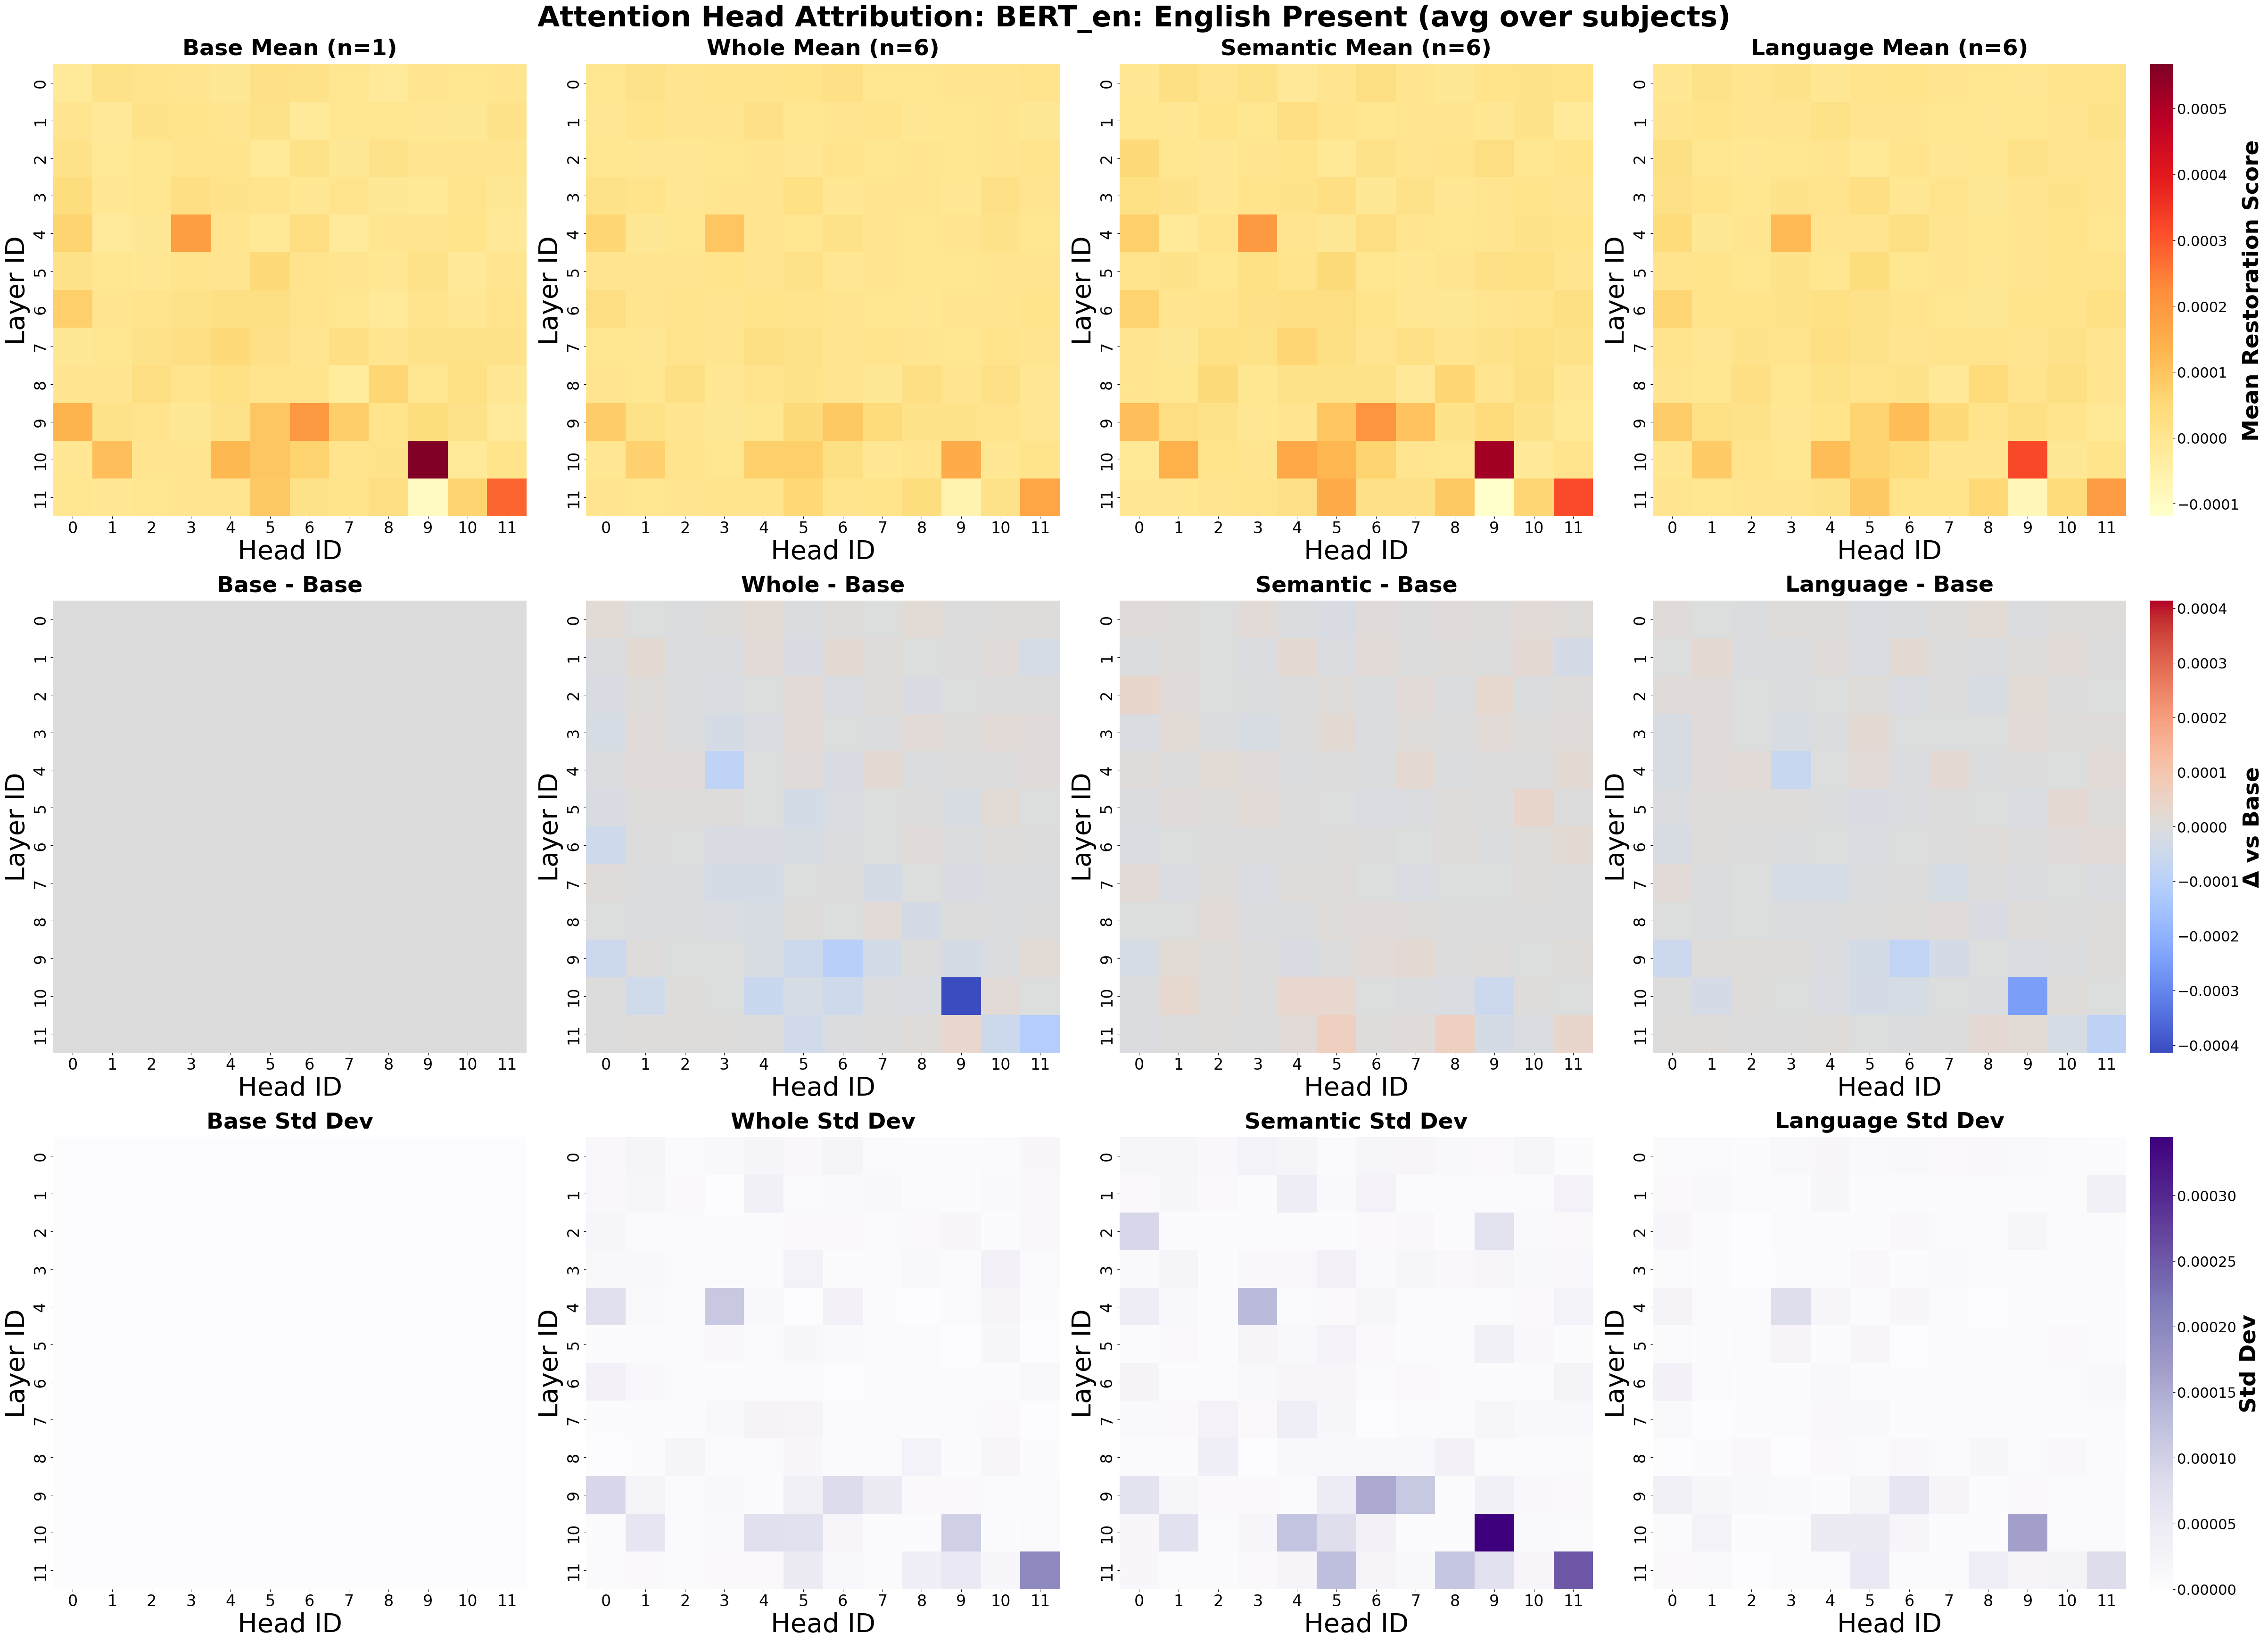

In [4]:
avg_res, std_results,  counts = patch_analyzer.load_family_attribution_avg(
    family_name="BERT_en",
    language="present_en",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="BERT_en: English Present (avg over subjects)")

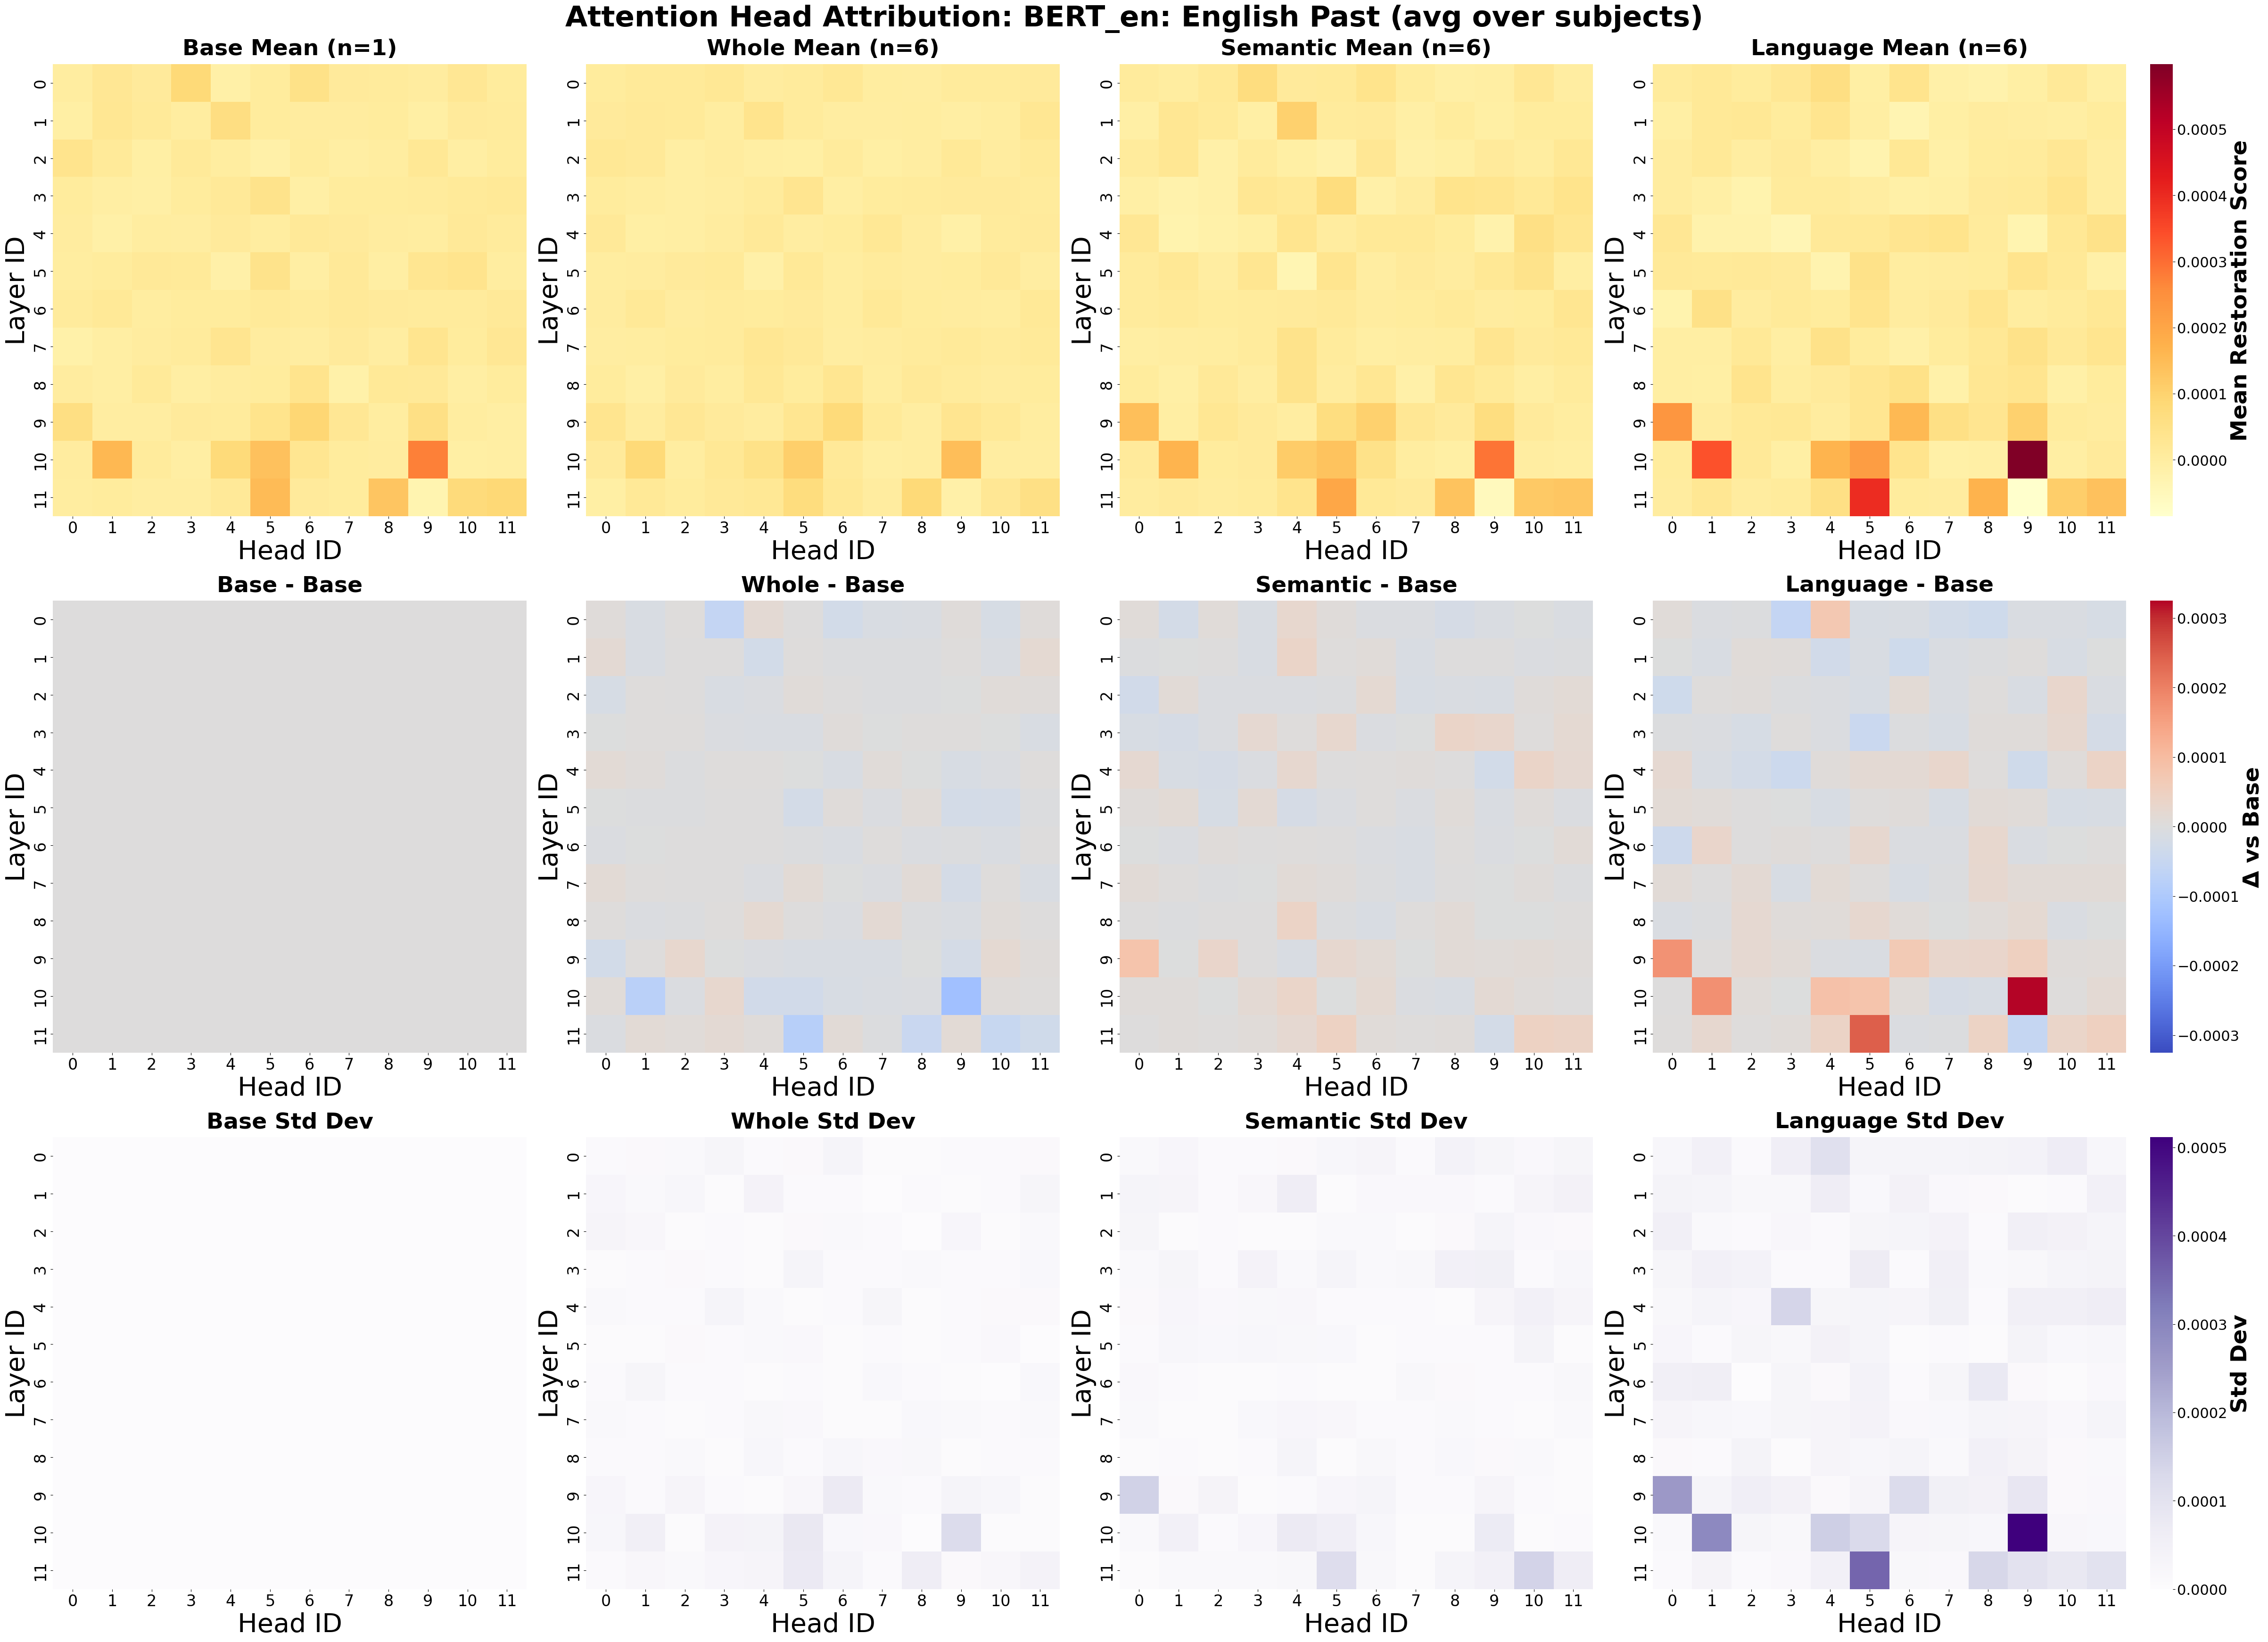

In [5]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="BERT_en",
    language="past_en",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="BERT_en: English Past (avg over subjects)")

# BERT_zh

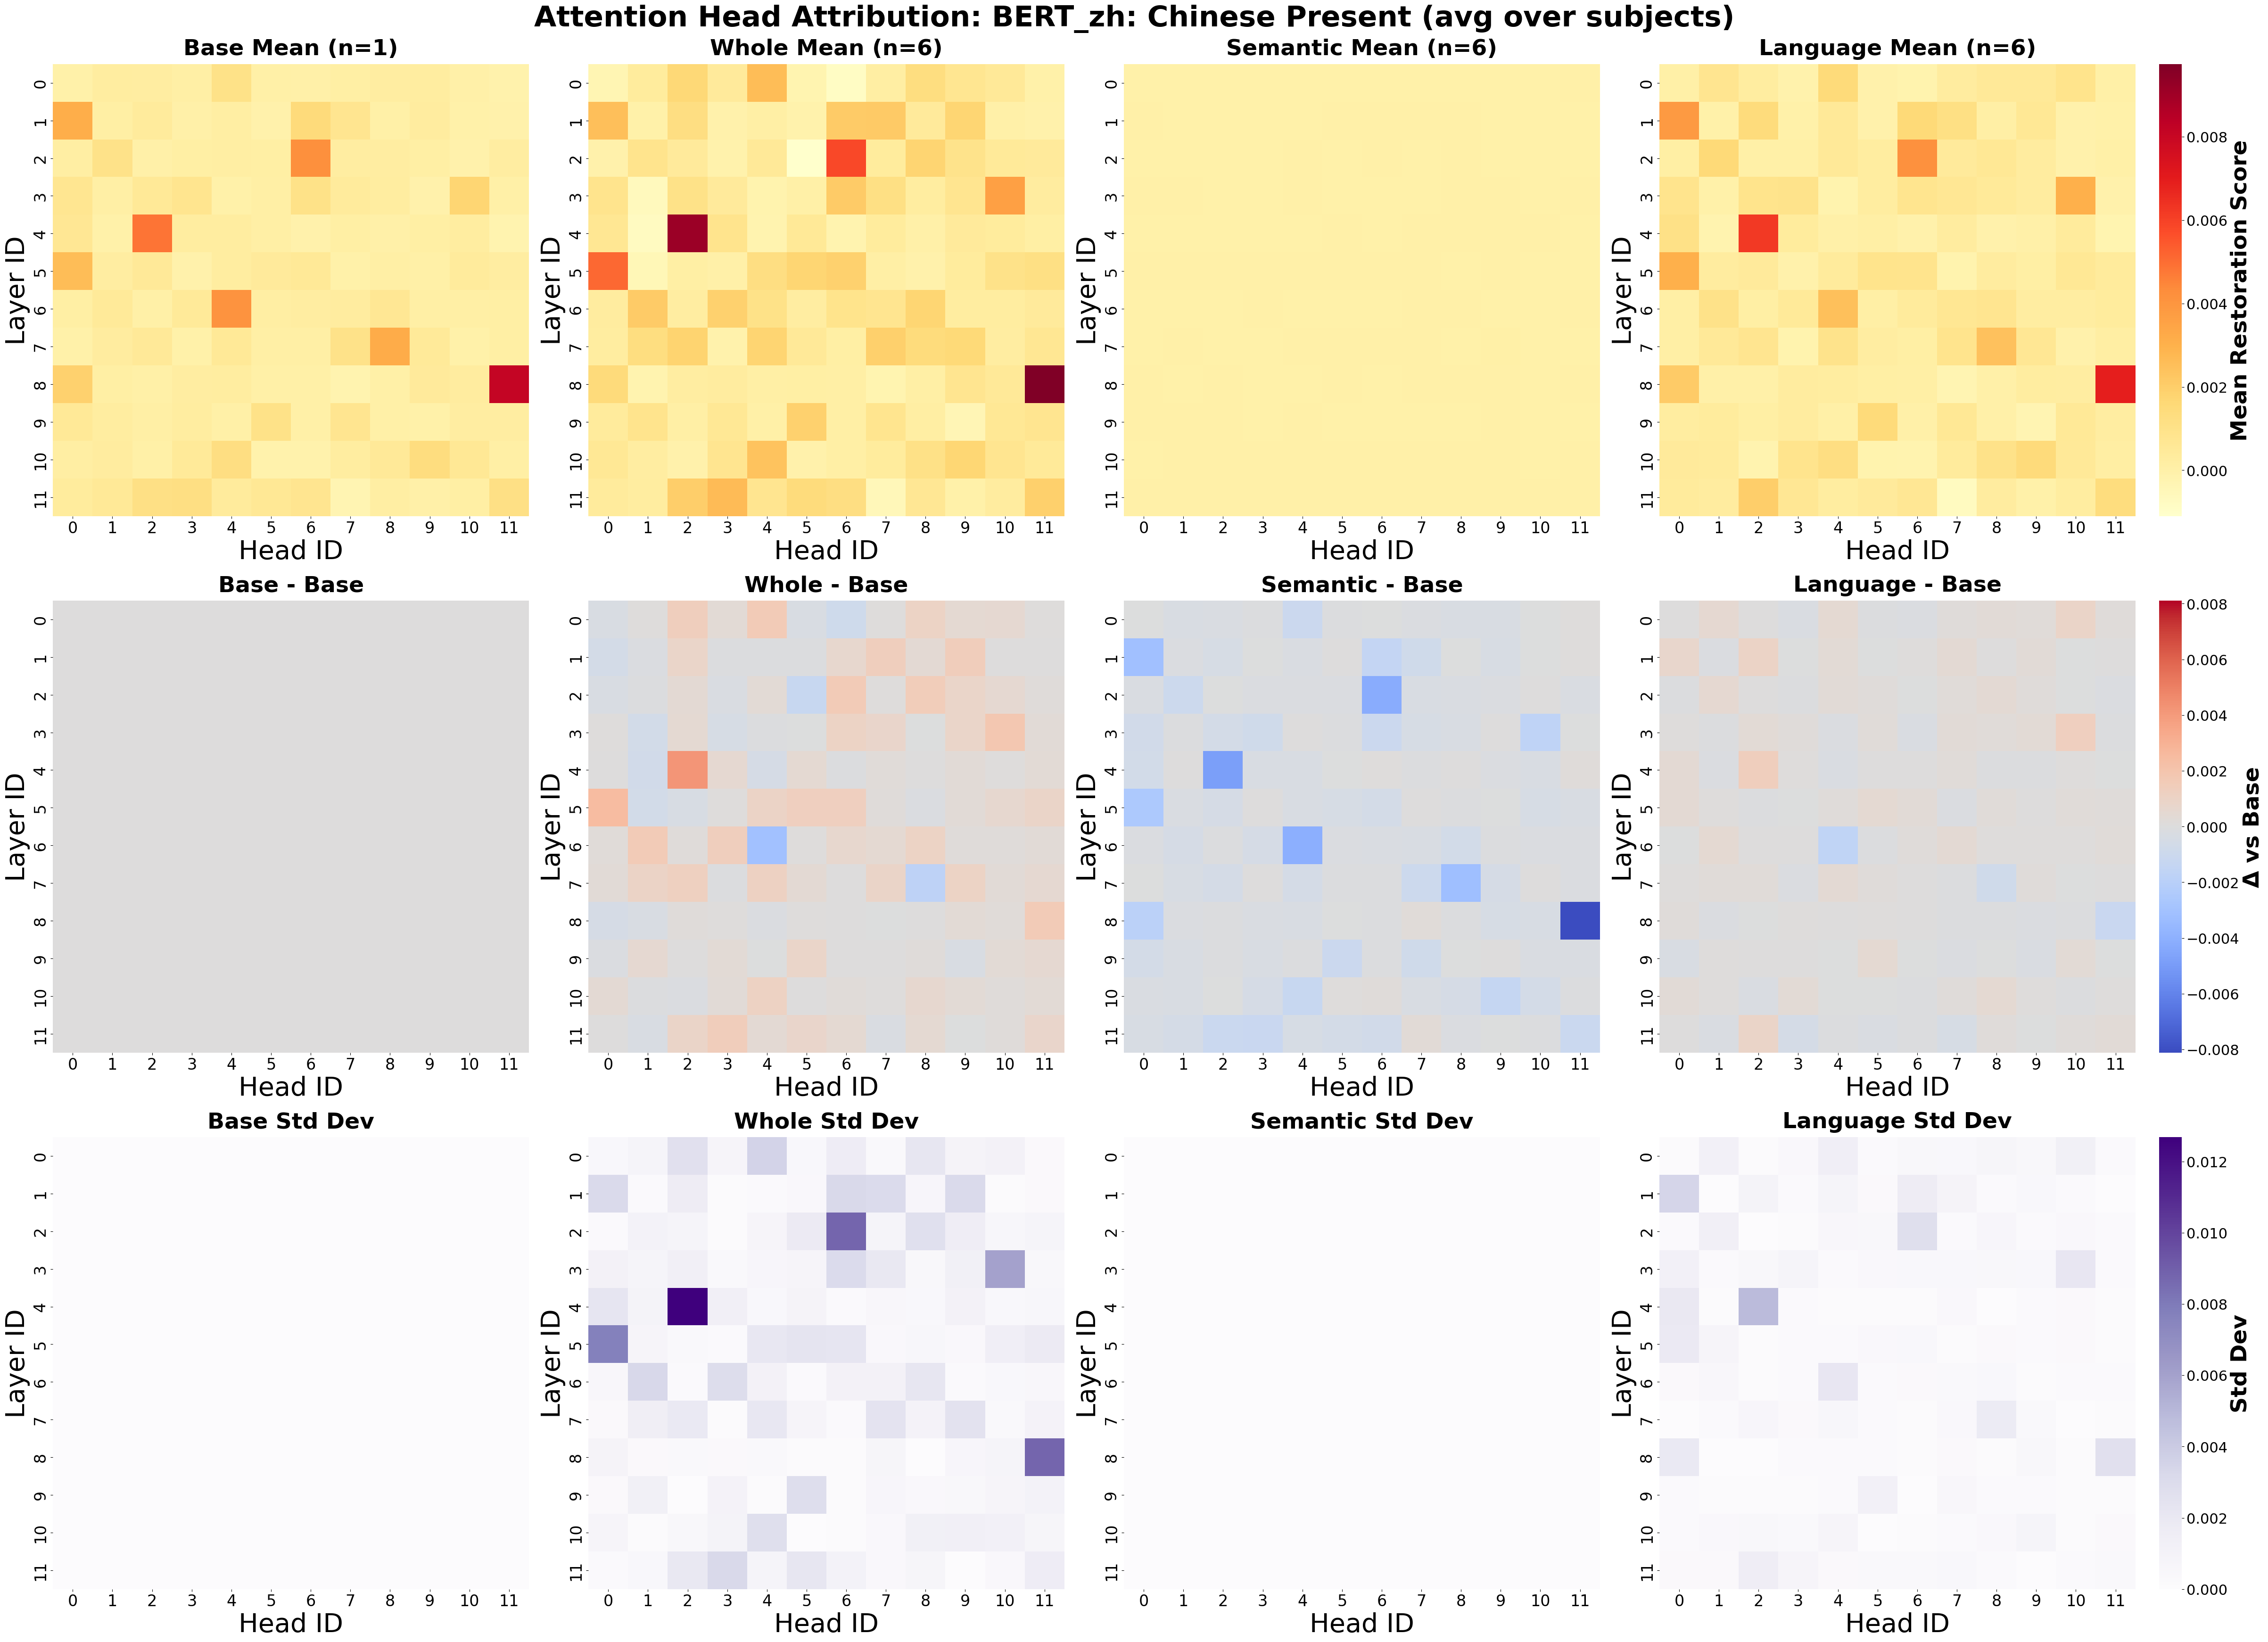

In [6]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="BERT_zh",
    language="present_zh",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="BERT_zh: Chinese Present (avg over subjects)")

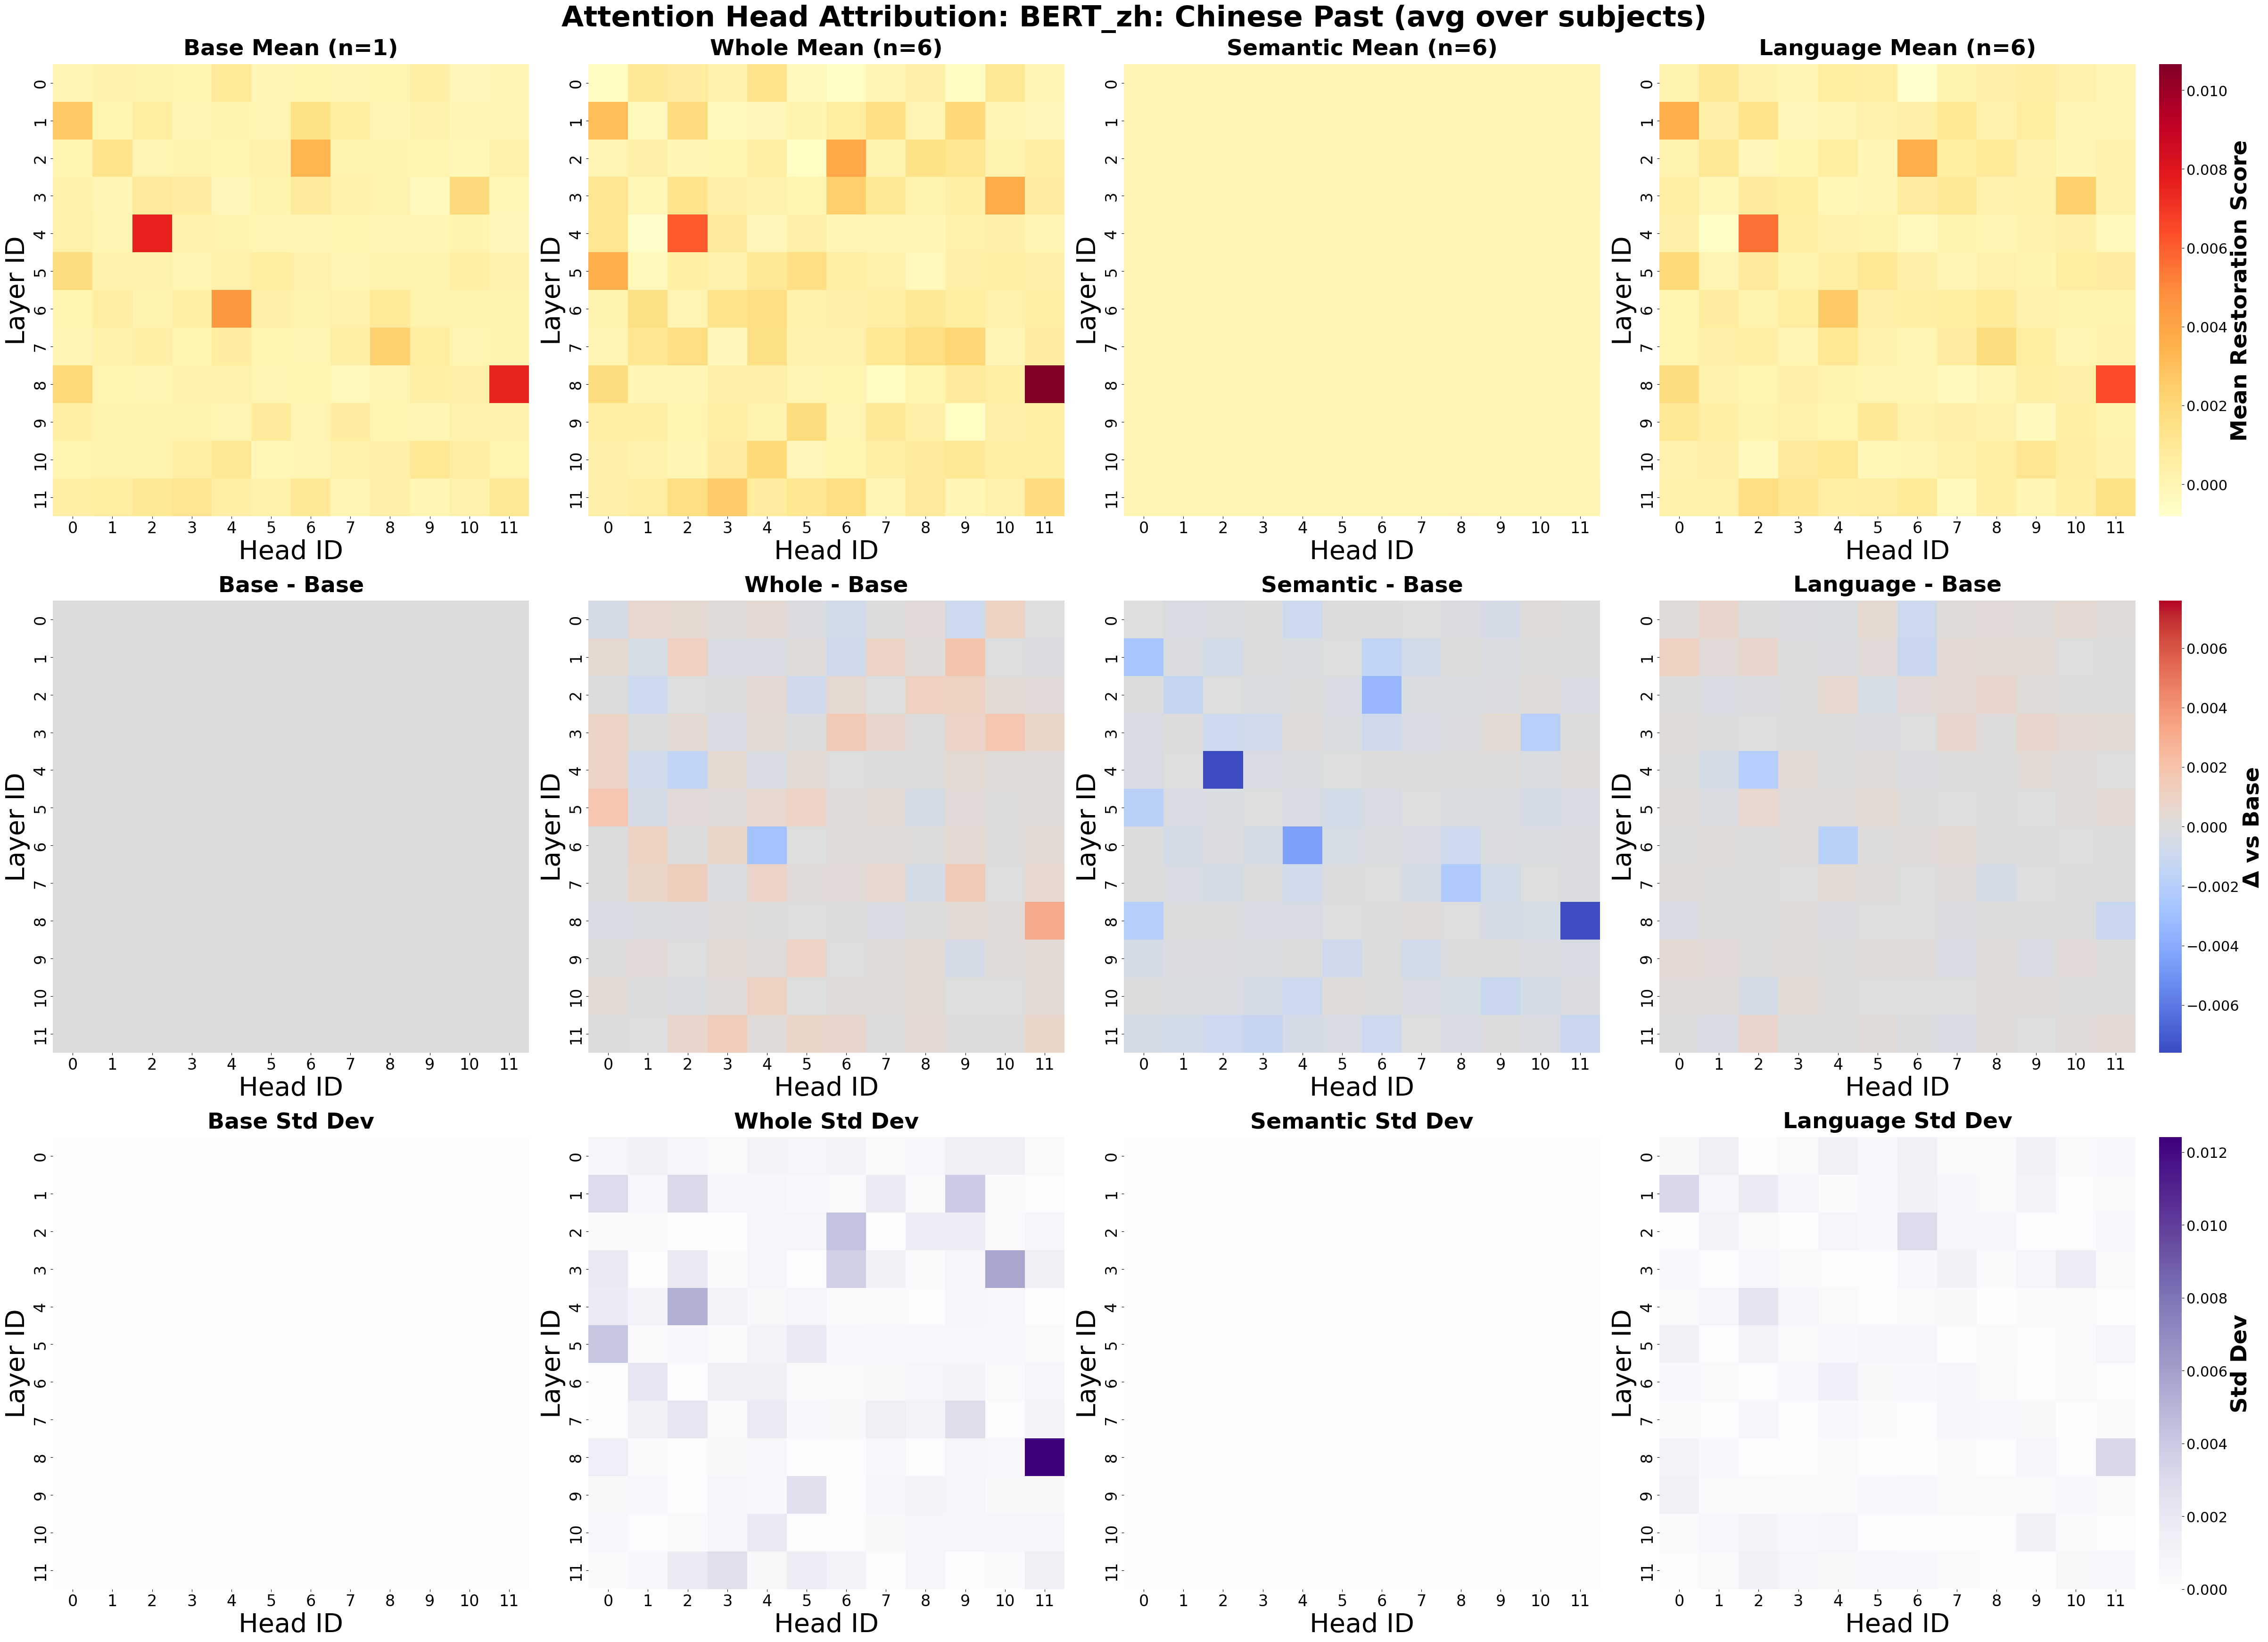

In [7]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="BERT_zh",
    language="past_zh",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="BERT_zh: Chinese Past (avg over subjects)")

# mBERT-en

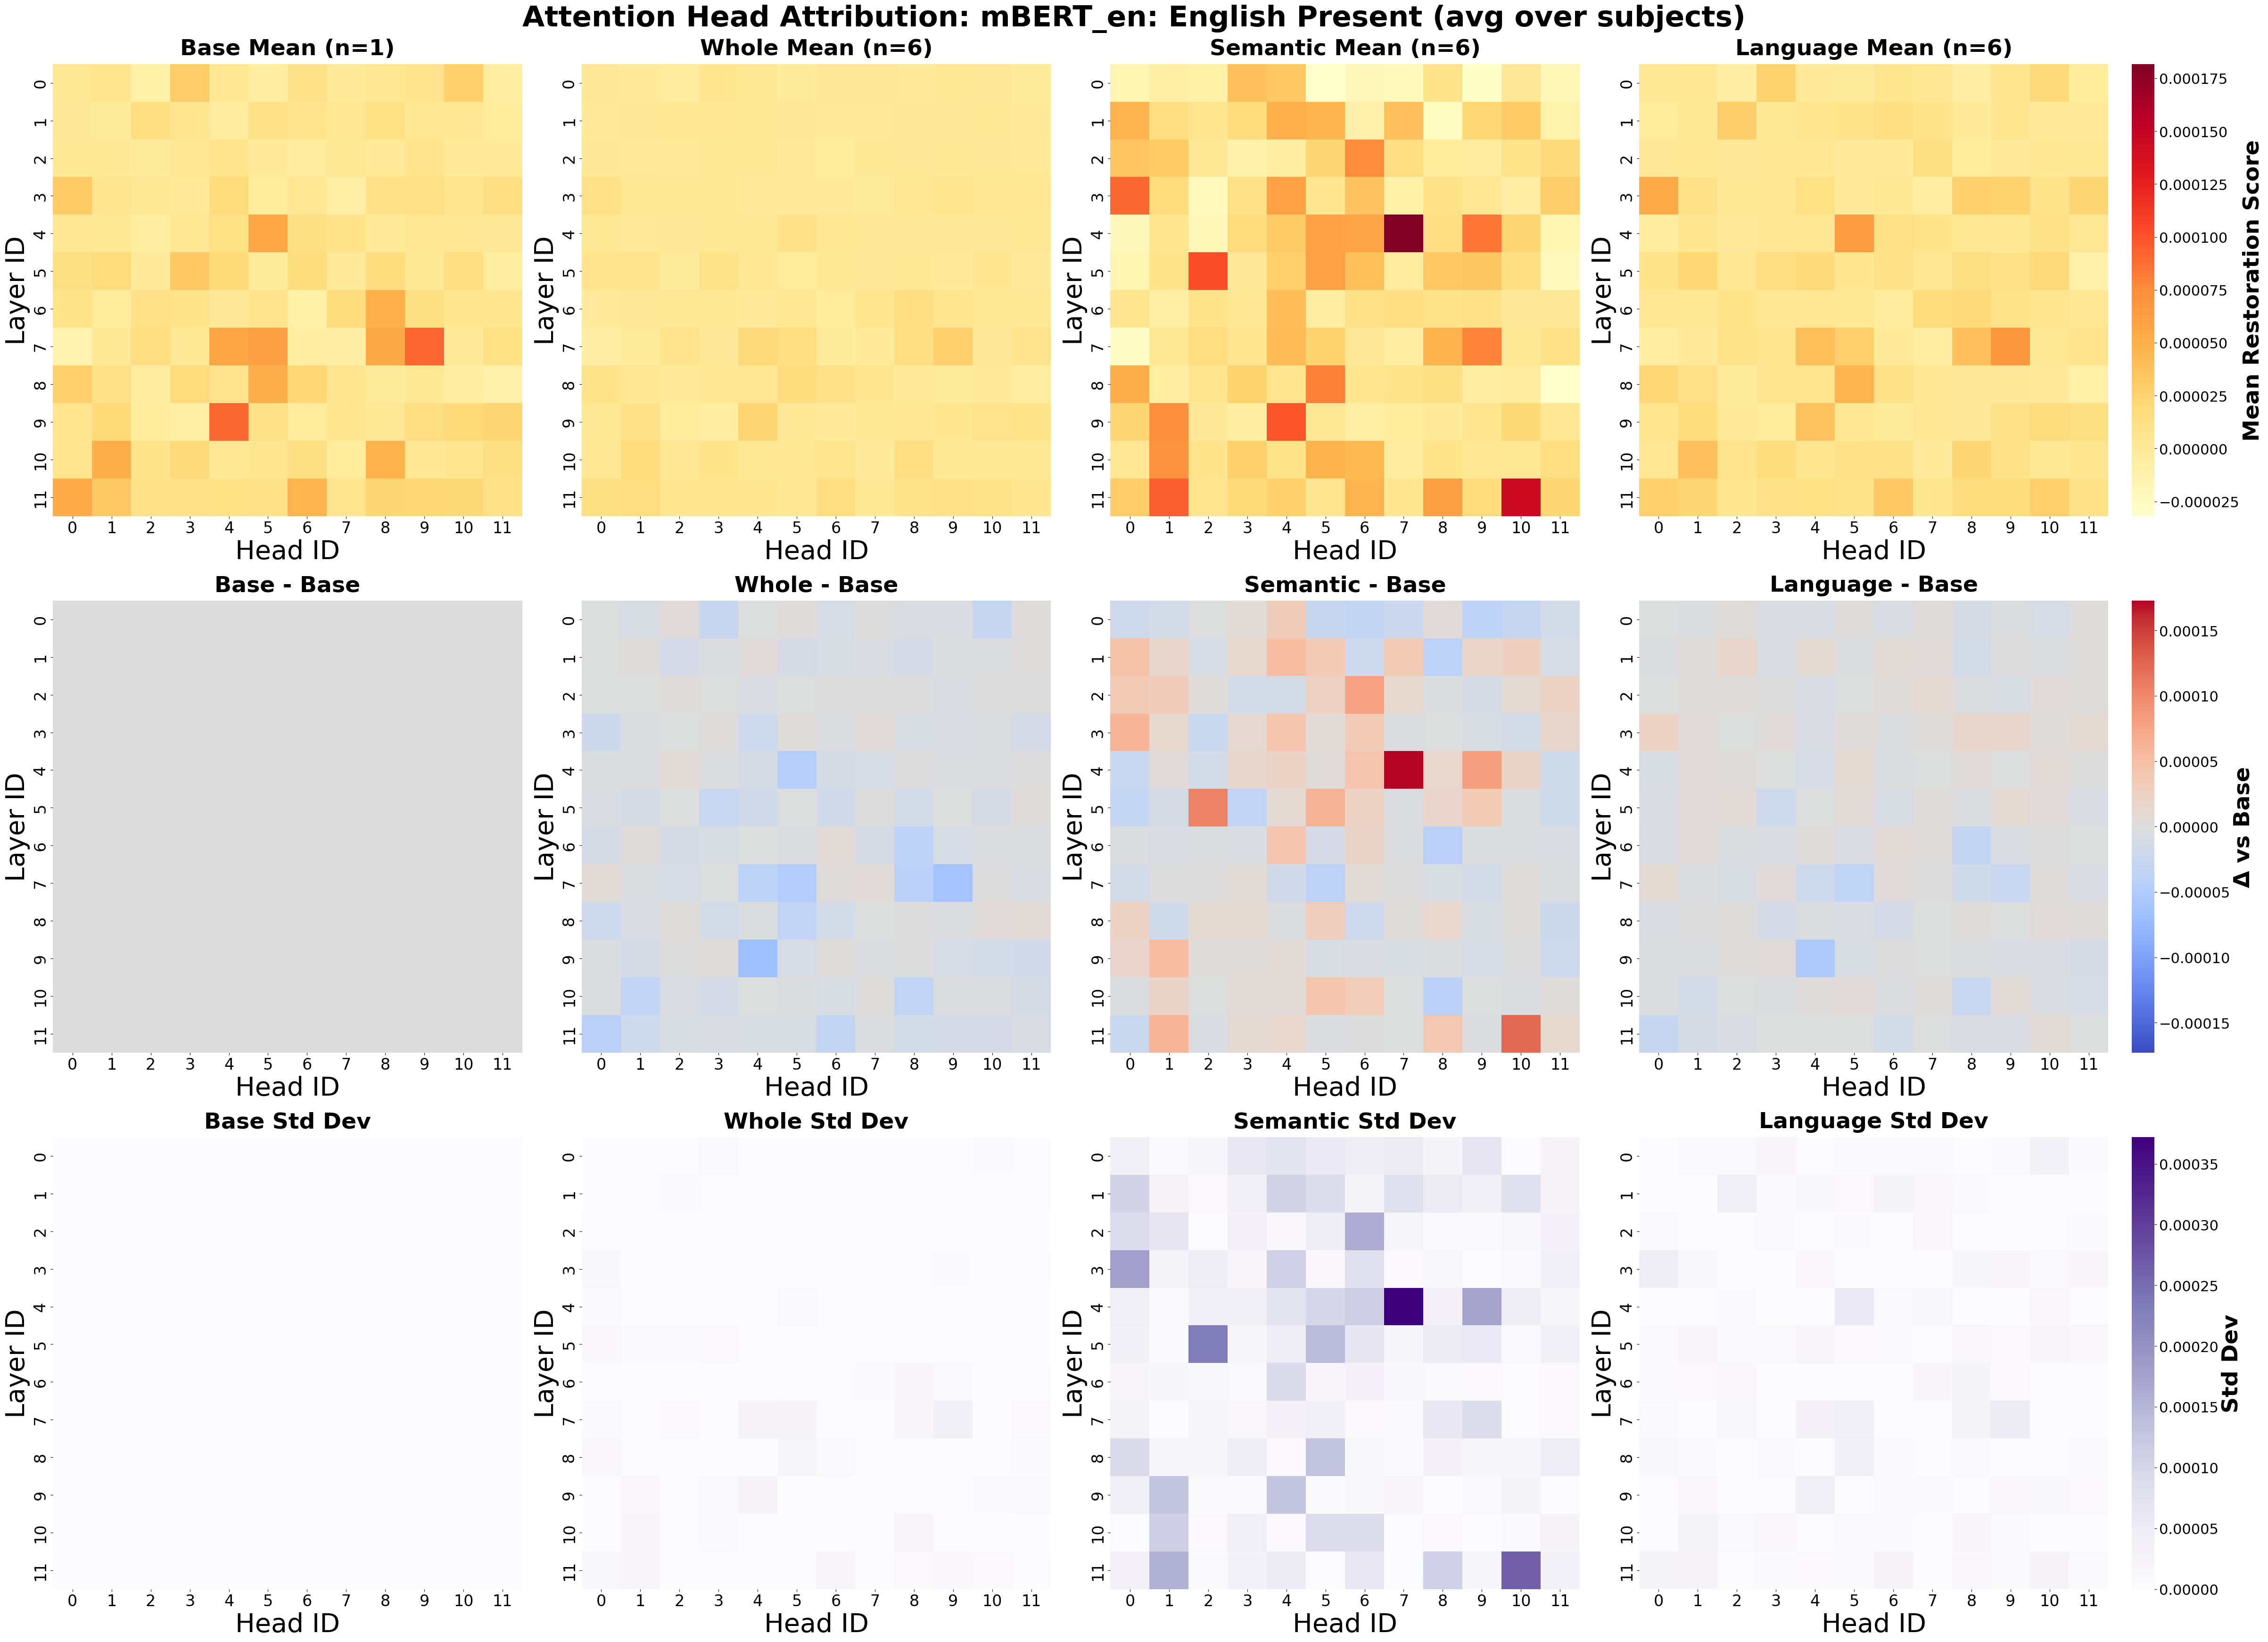

In [8]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="mBERT_en",
    language="present_en",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="mBERT_en: English Present (avg over subjects)")

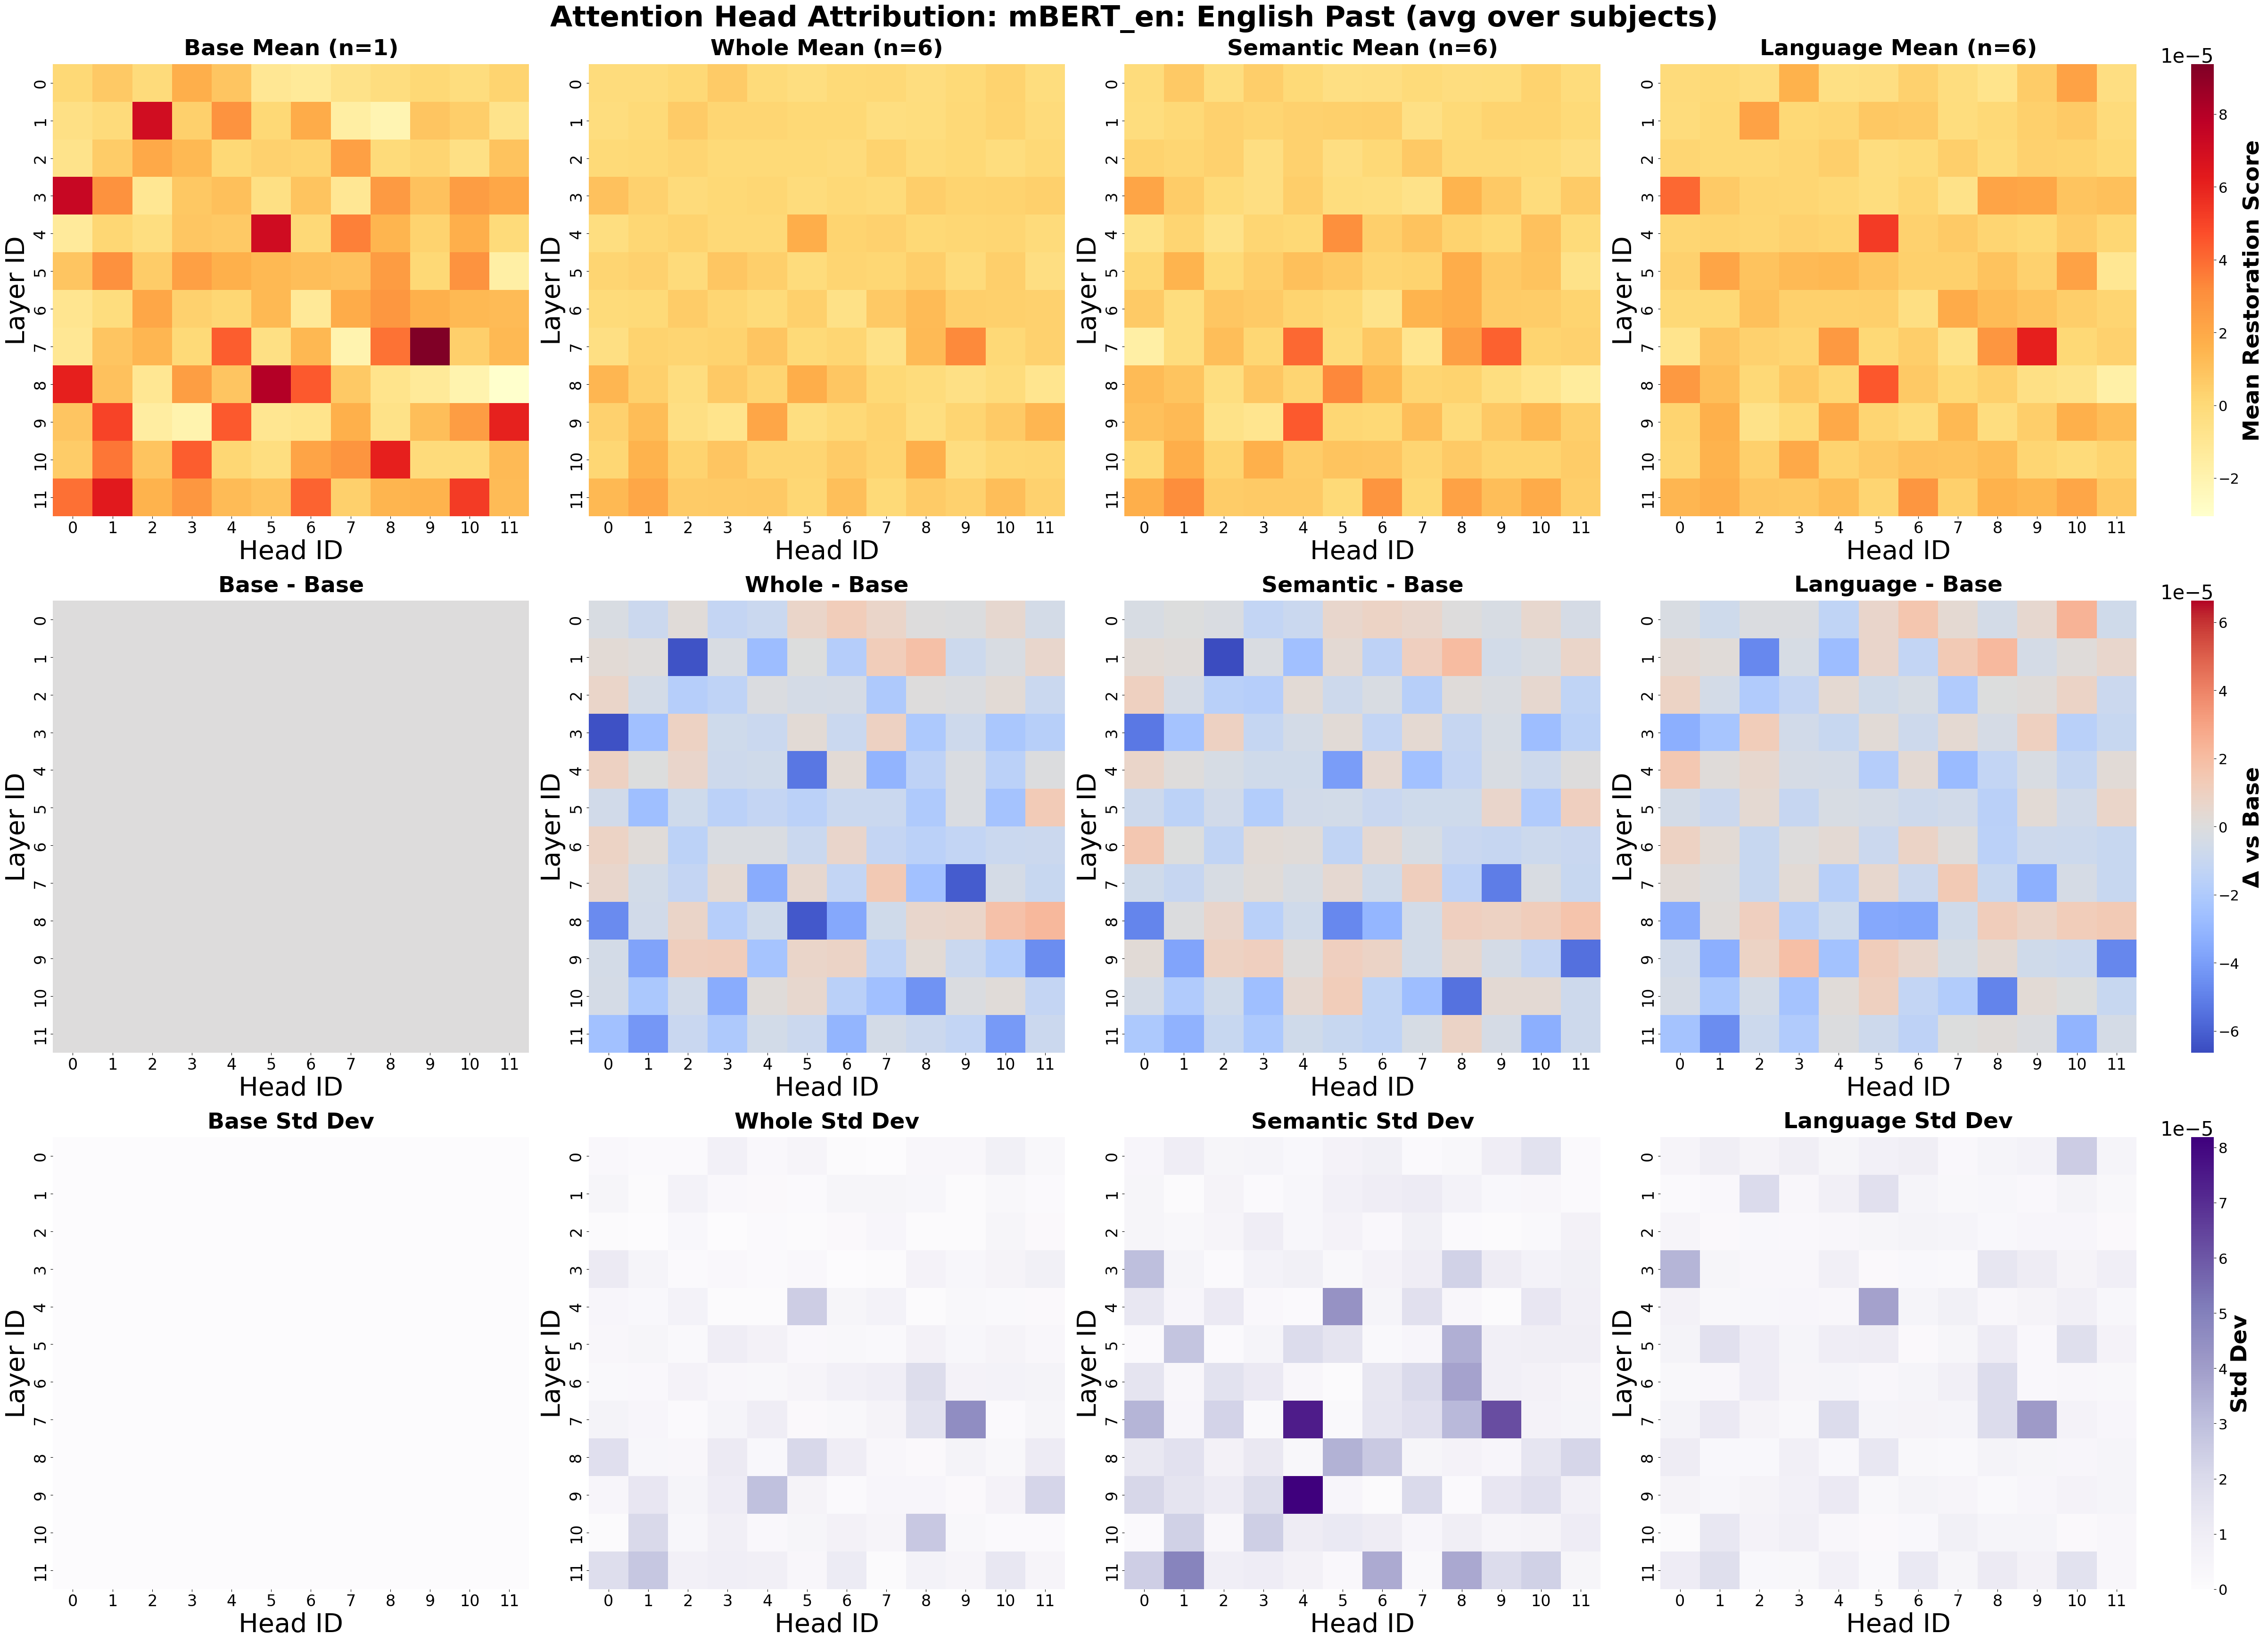

In [9]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="mBERT_en",
    language="past_en",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="mBERT_en: English Past (avg over subjects)")

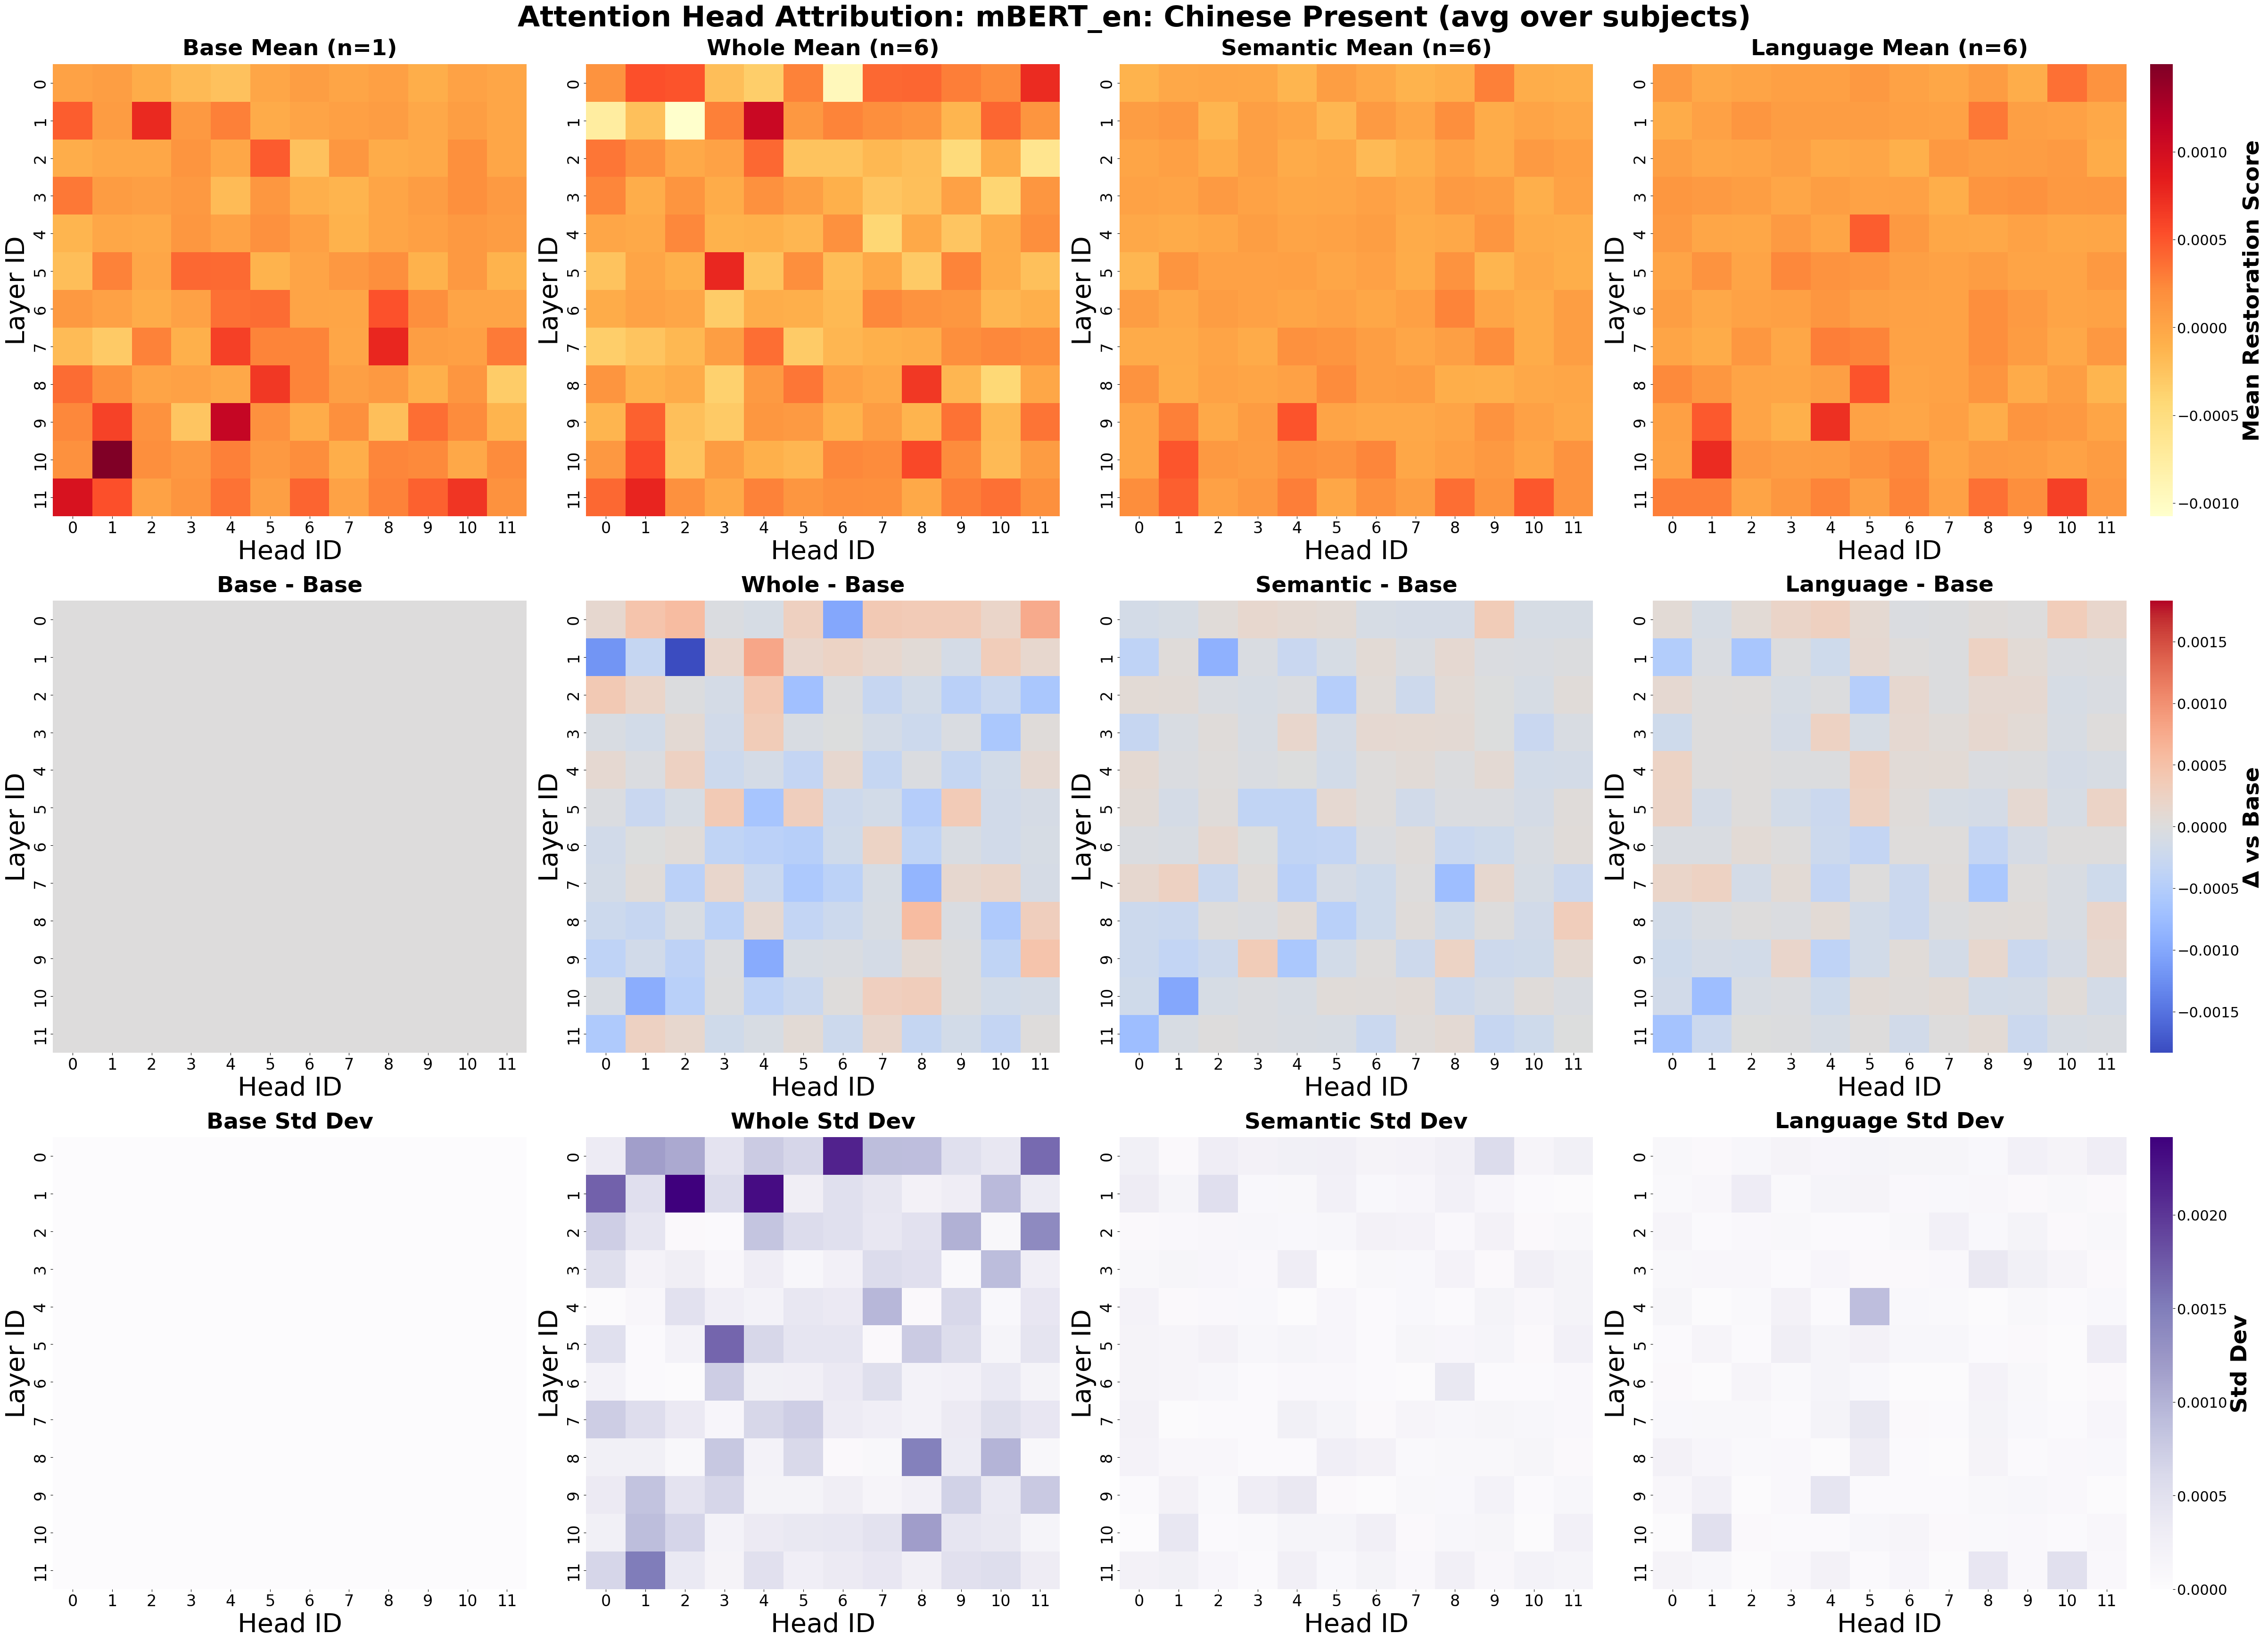

In [10]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="mBERT_en",
    language="present_zh",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="mBERT_en: Chinese Present (avg over subjects)")

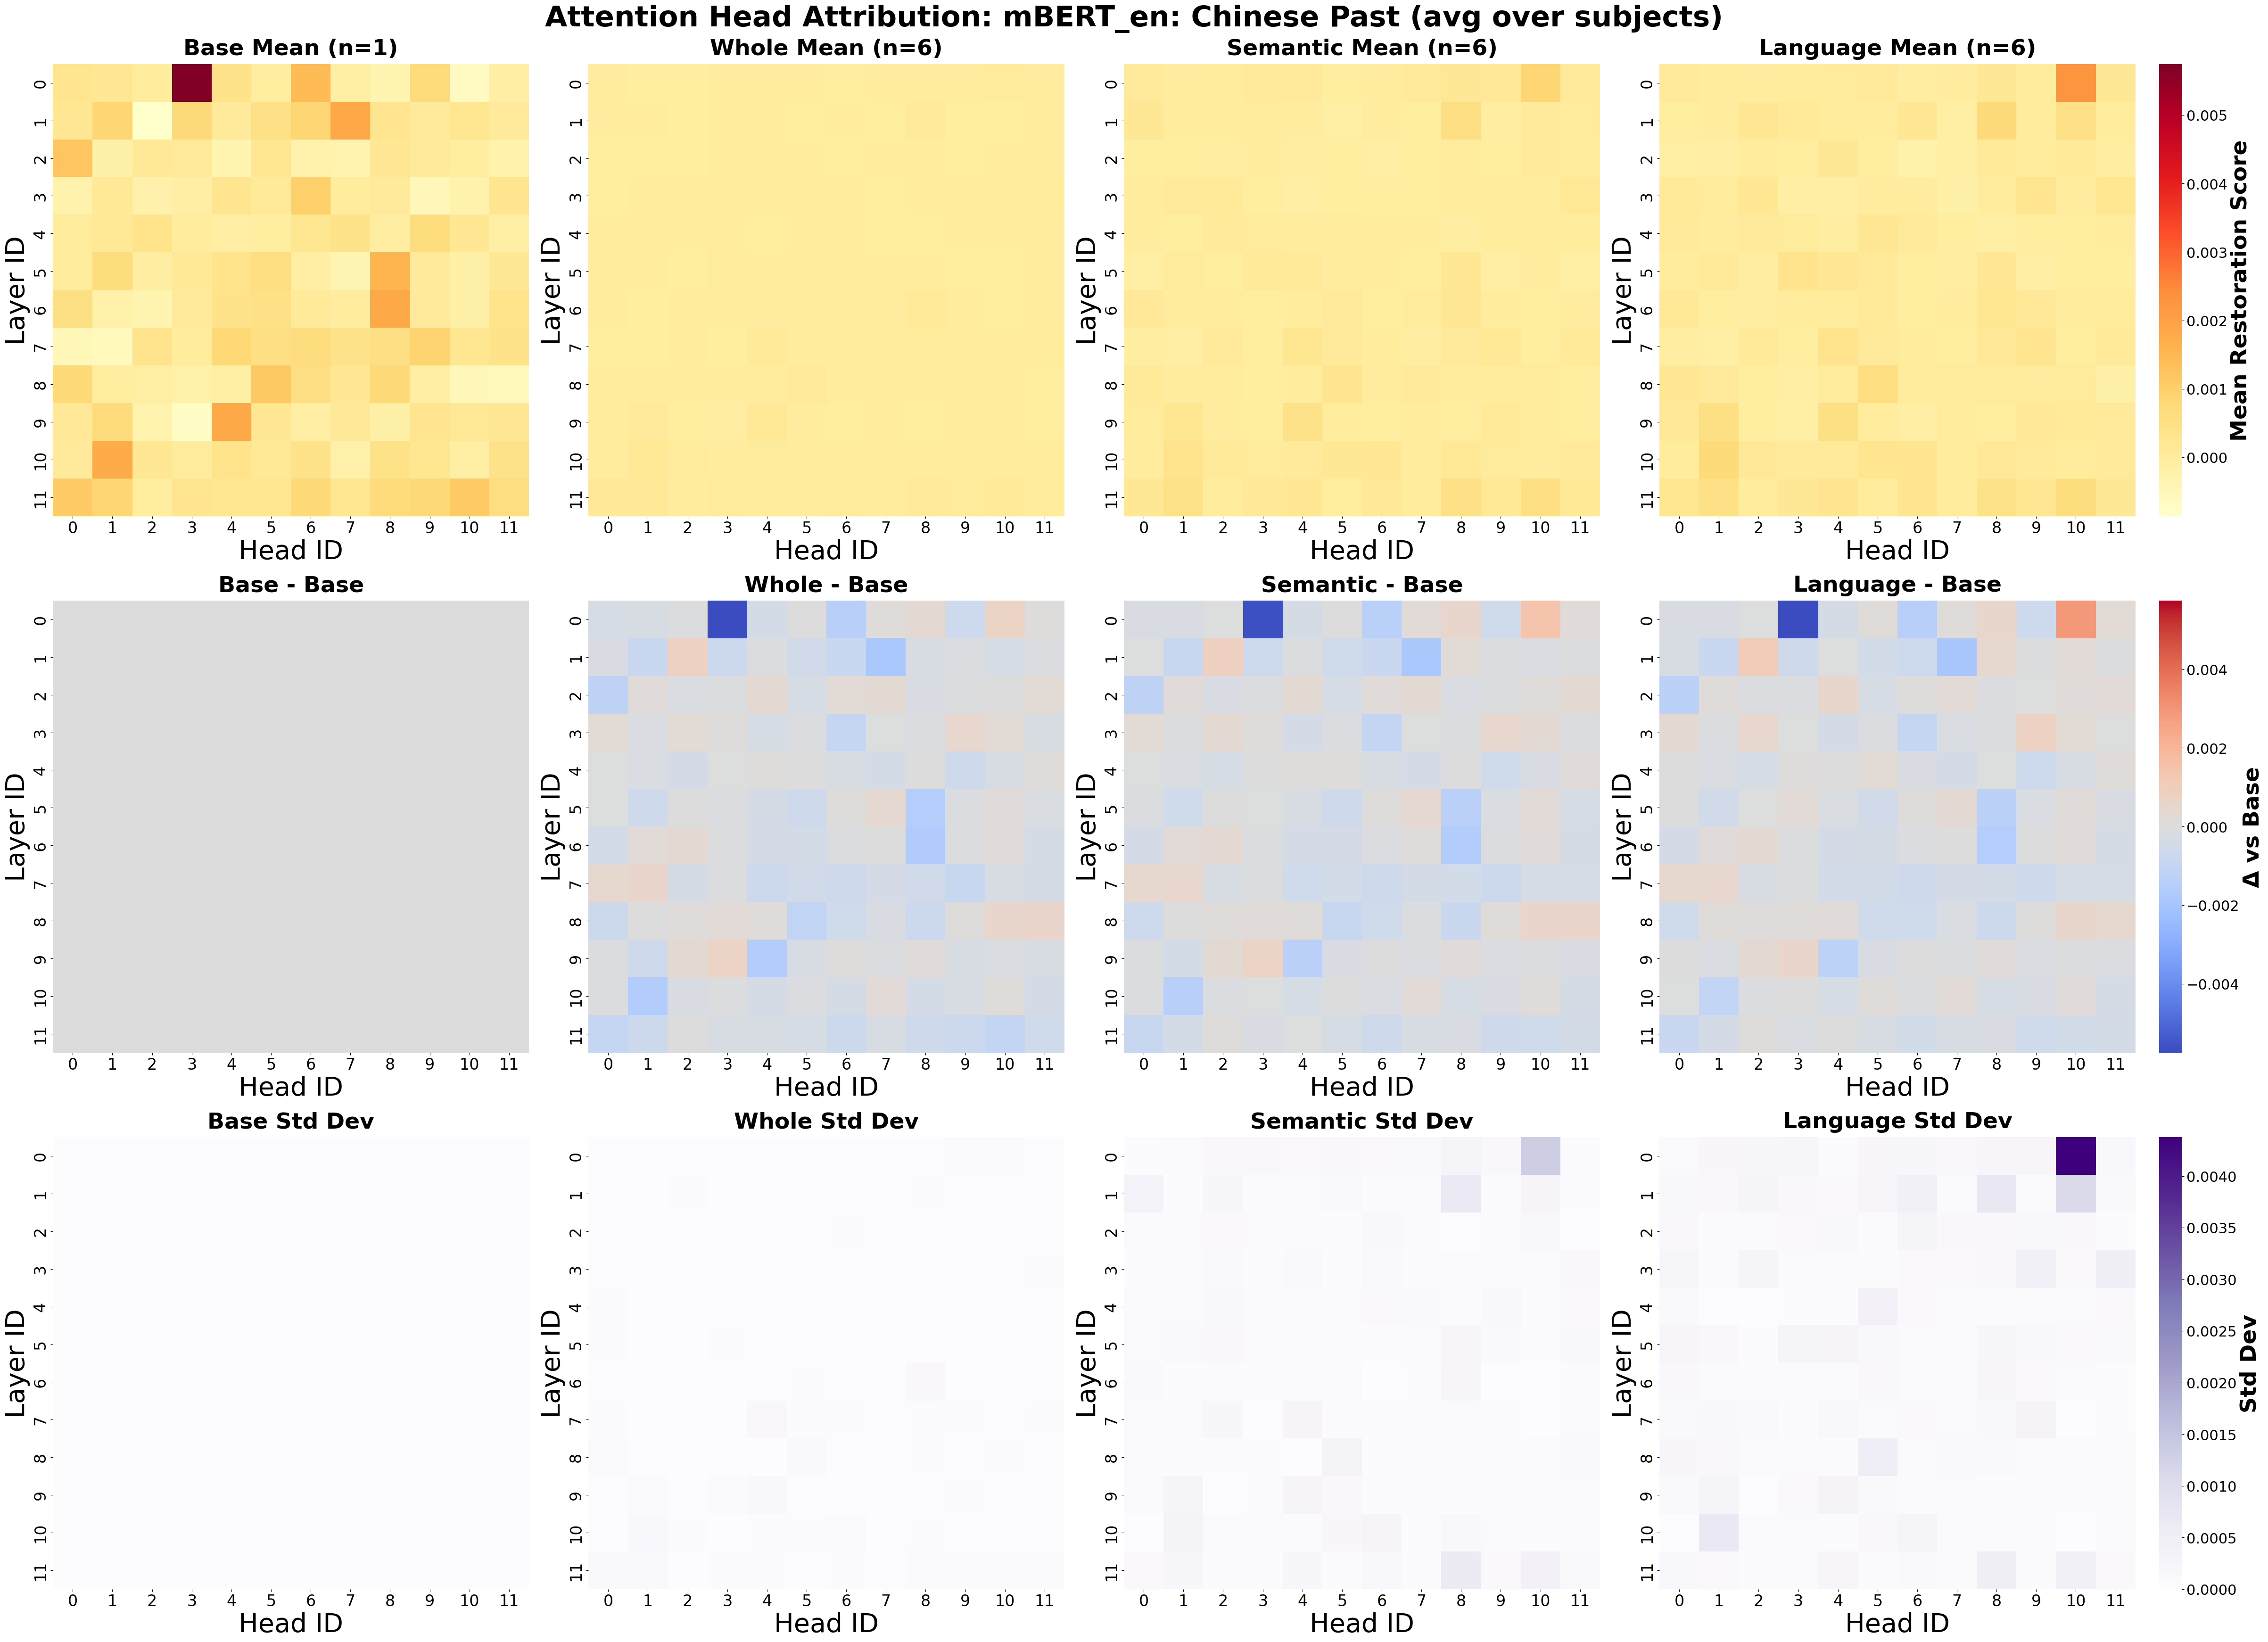

In [11]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="mBERT_en",
    language="past_zh",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="mBERT_en: Chinese Past (avg over subjects)")

# mBERT-zh

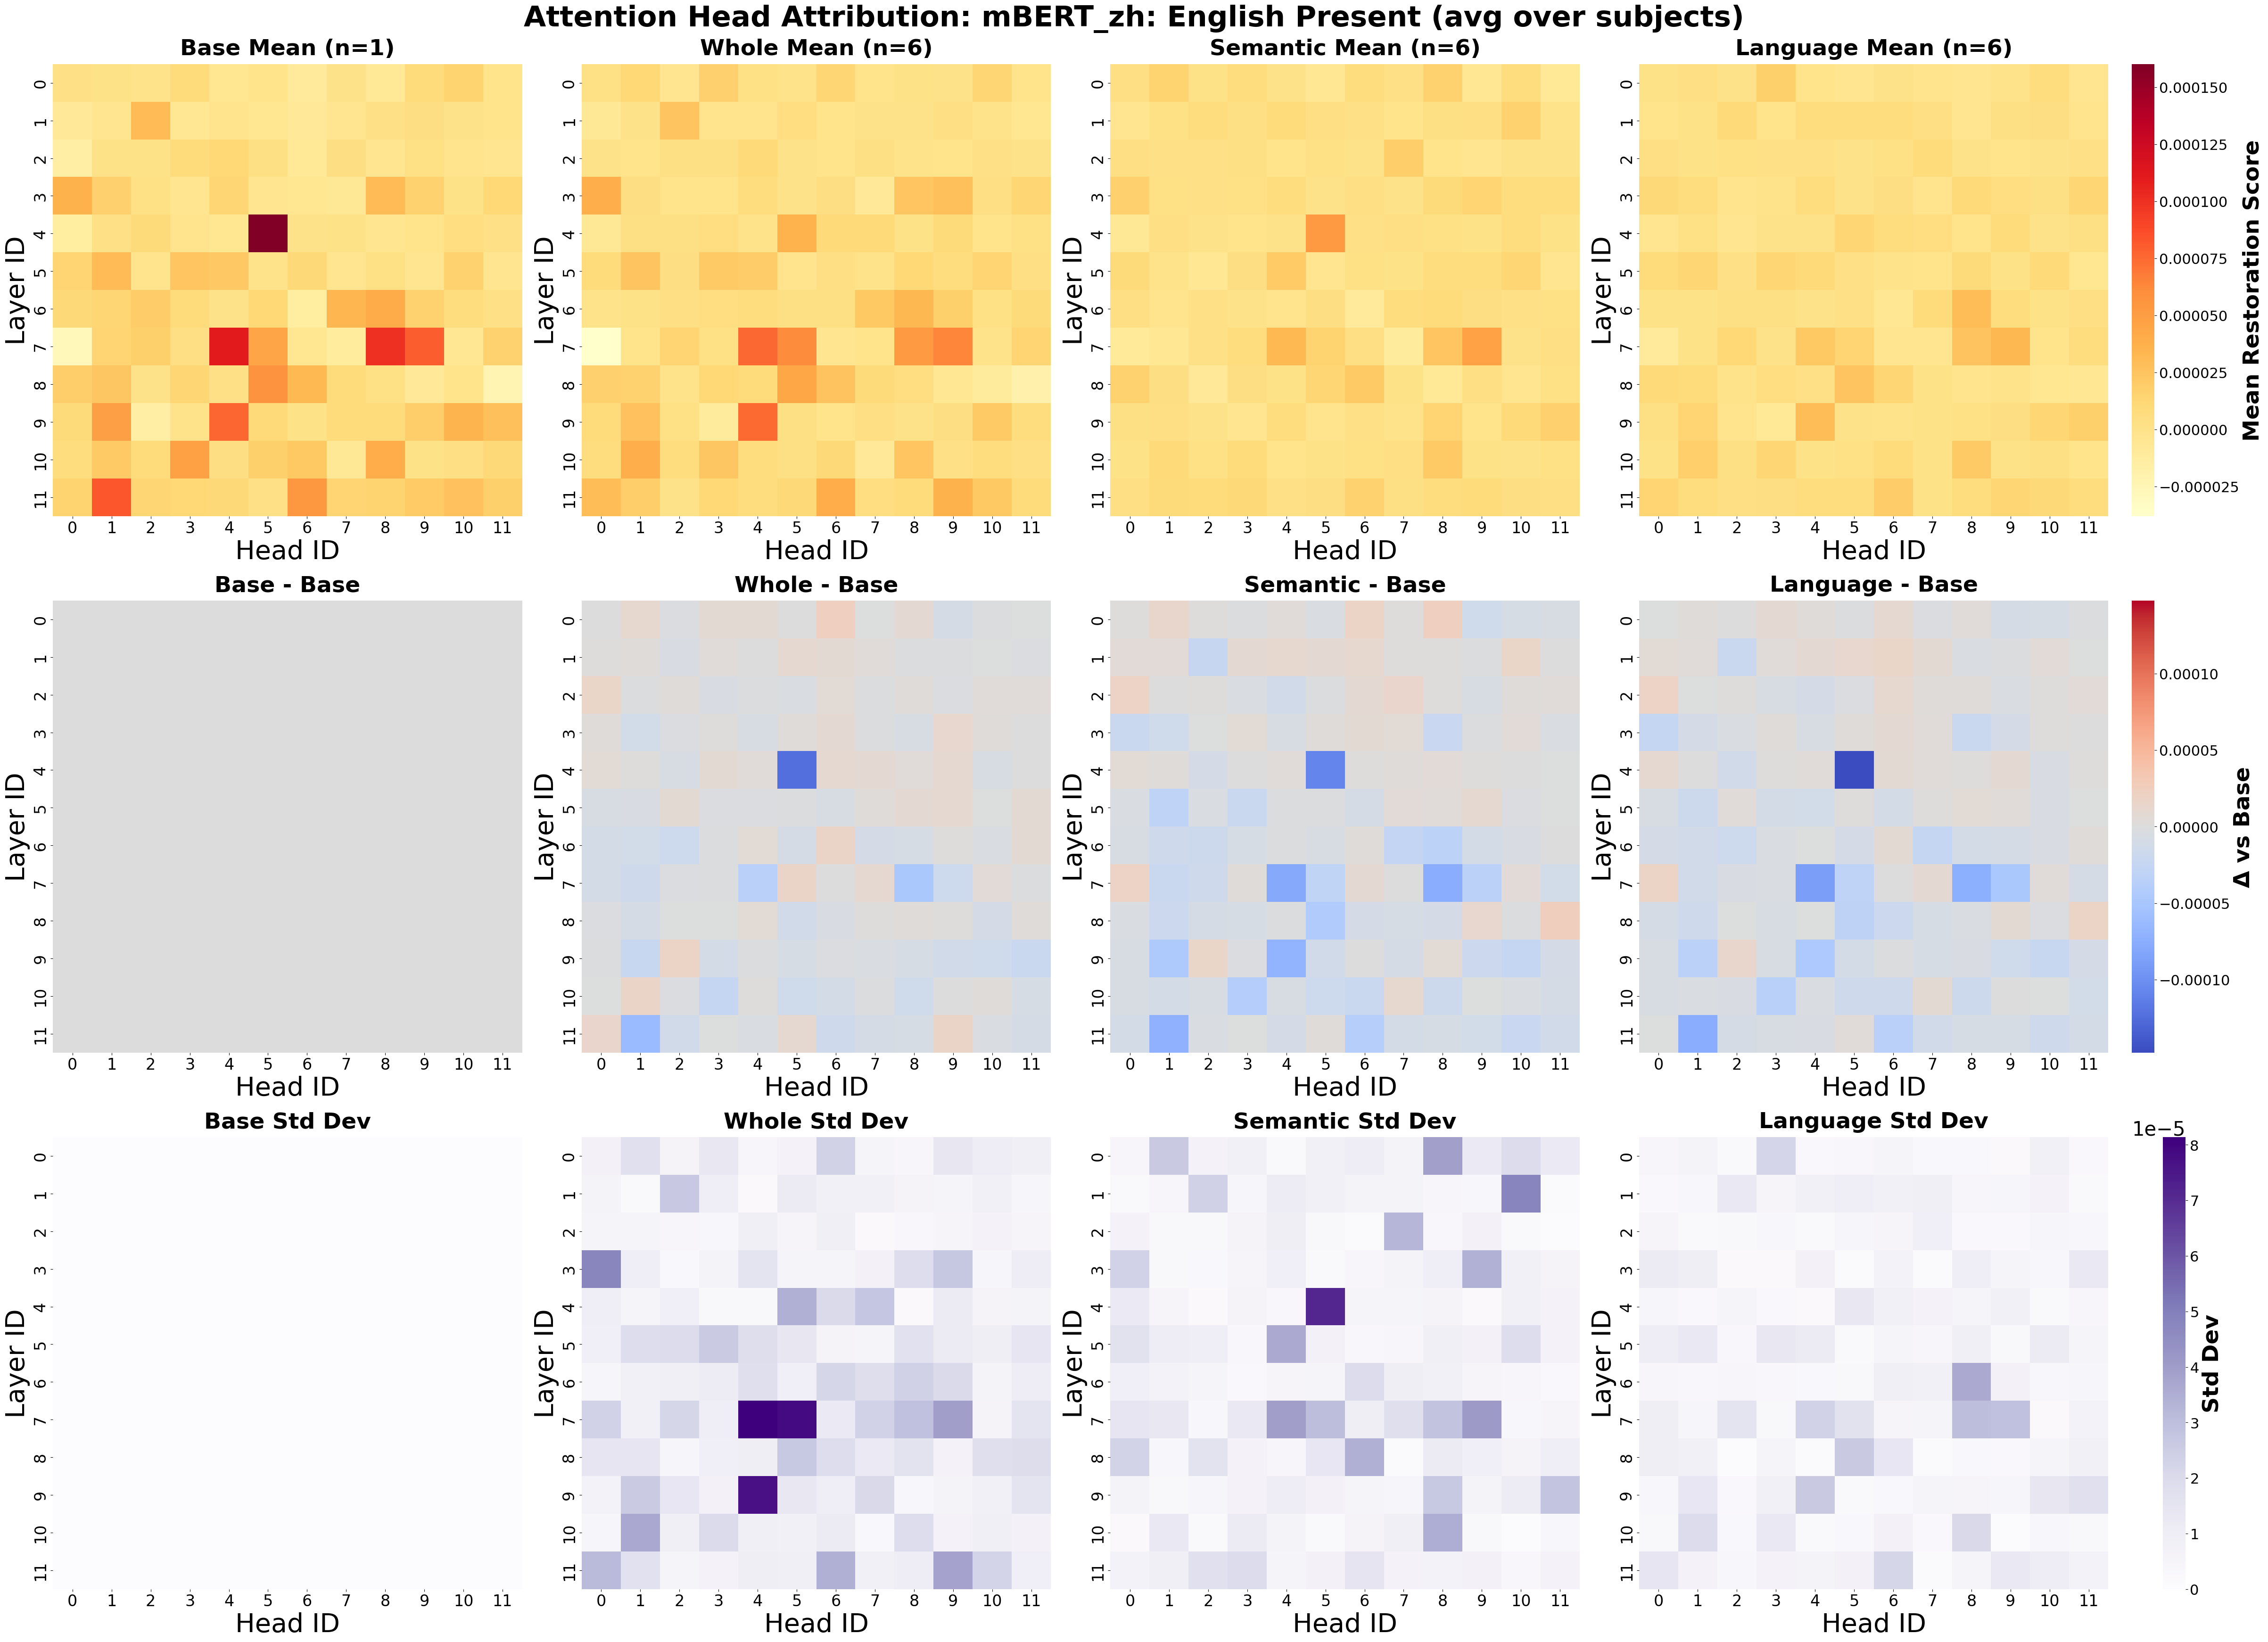

In [12]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="mBERT_zh",
    language="present_en",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="mBERT_zh: English Present (avg over subjects)")

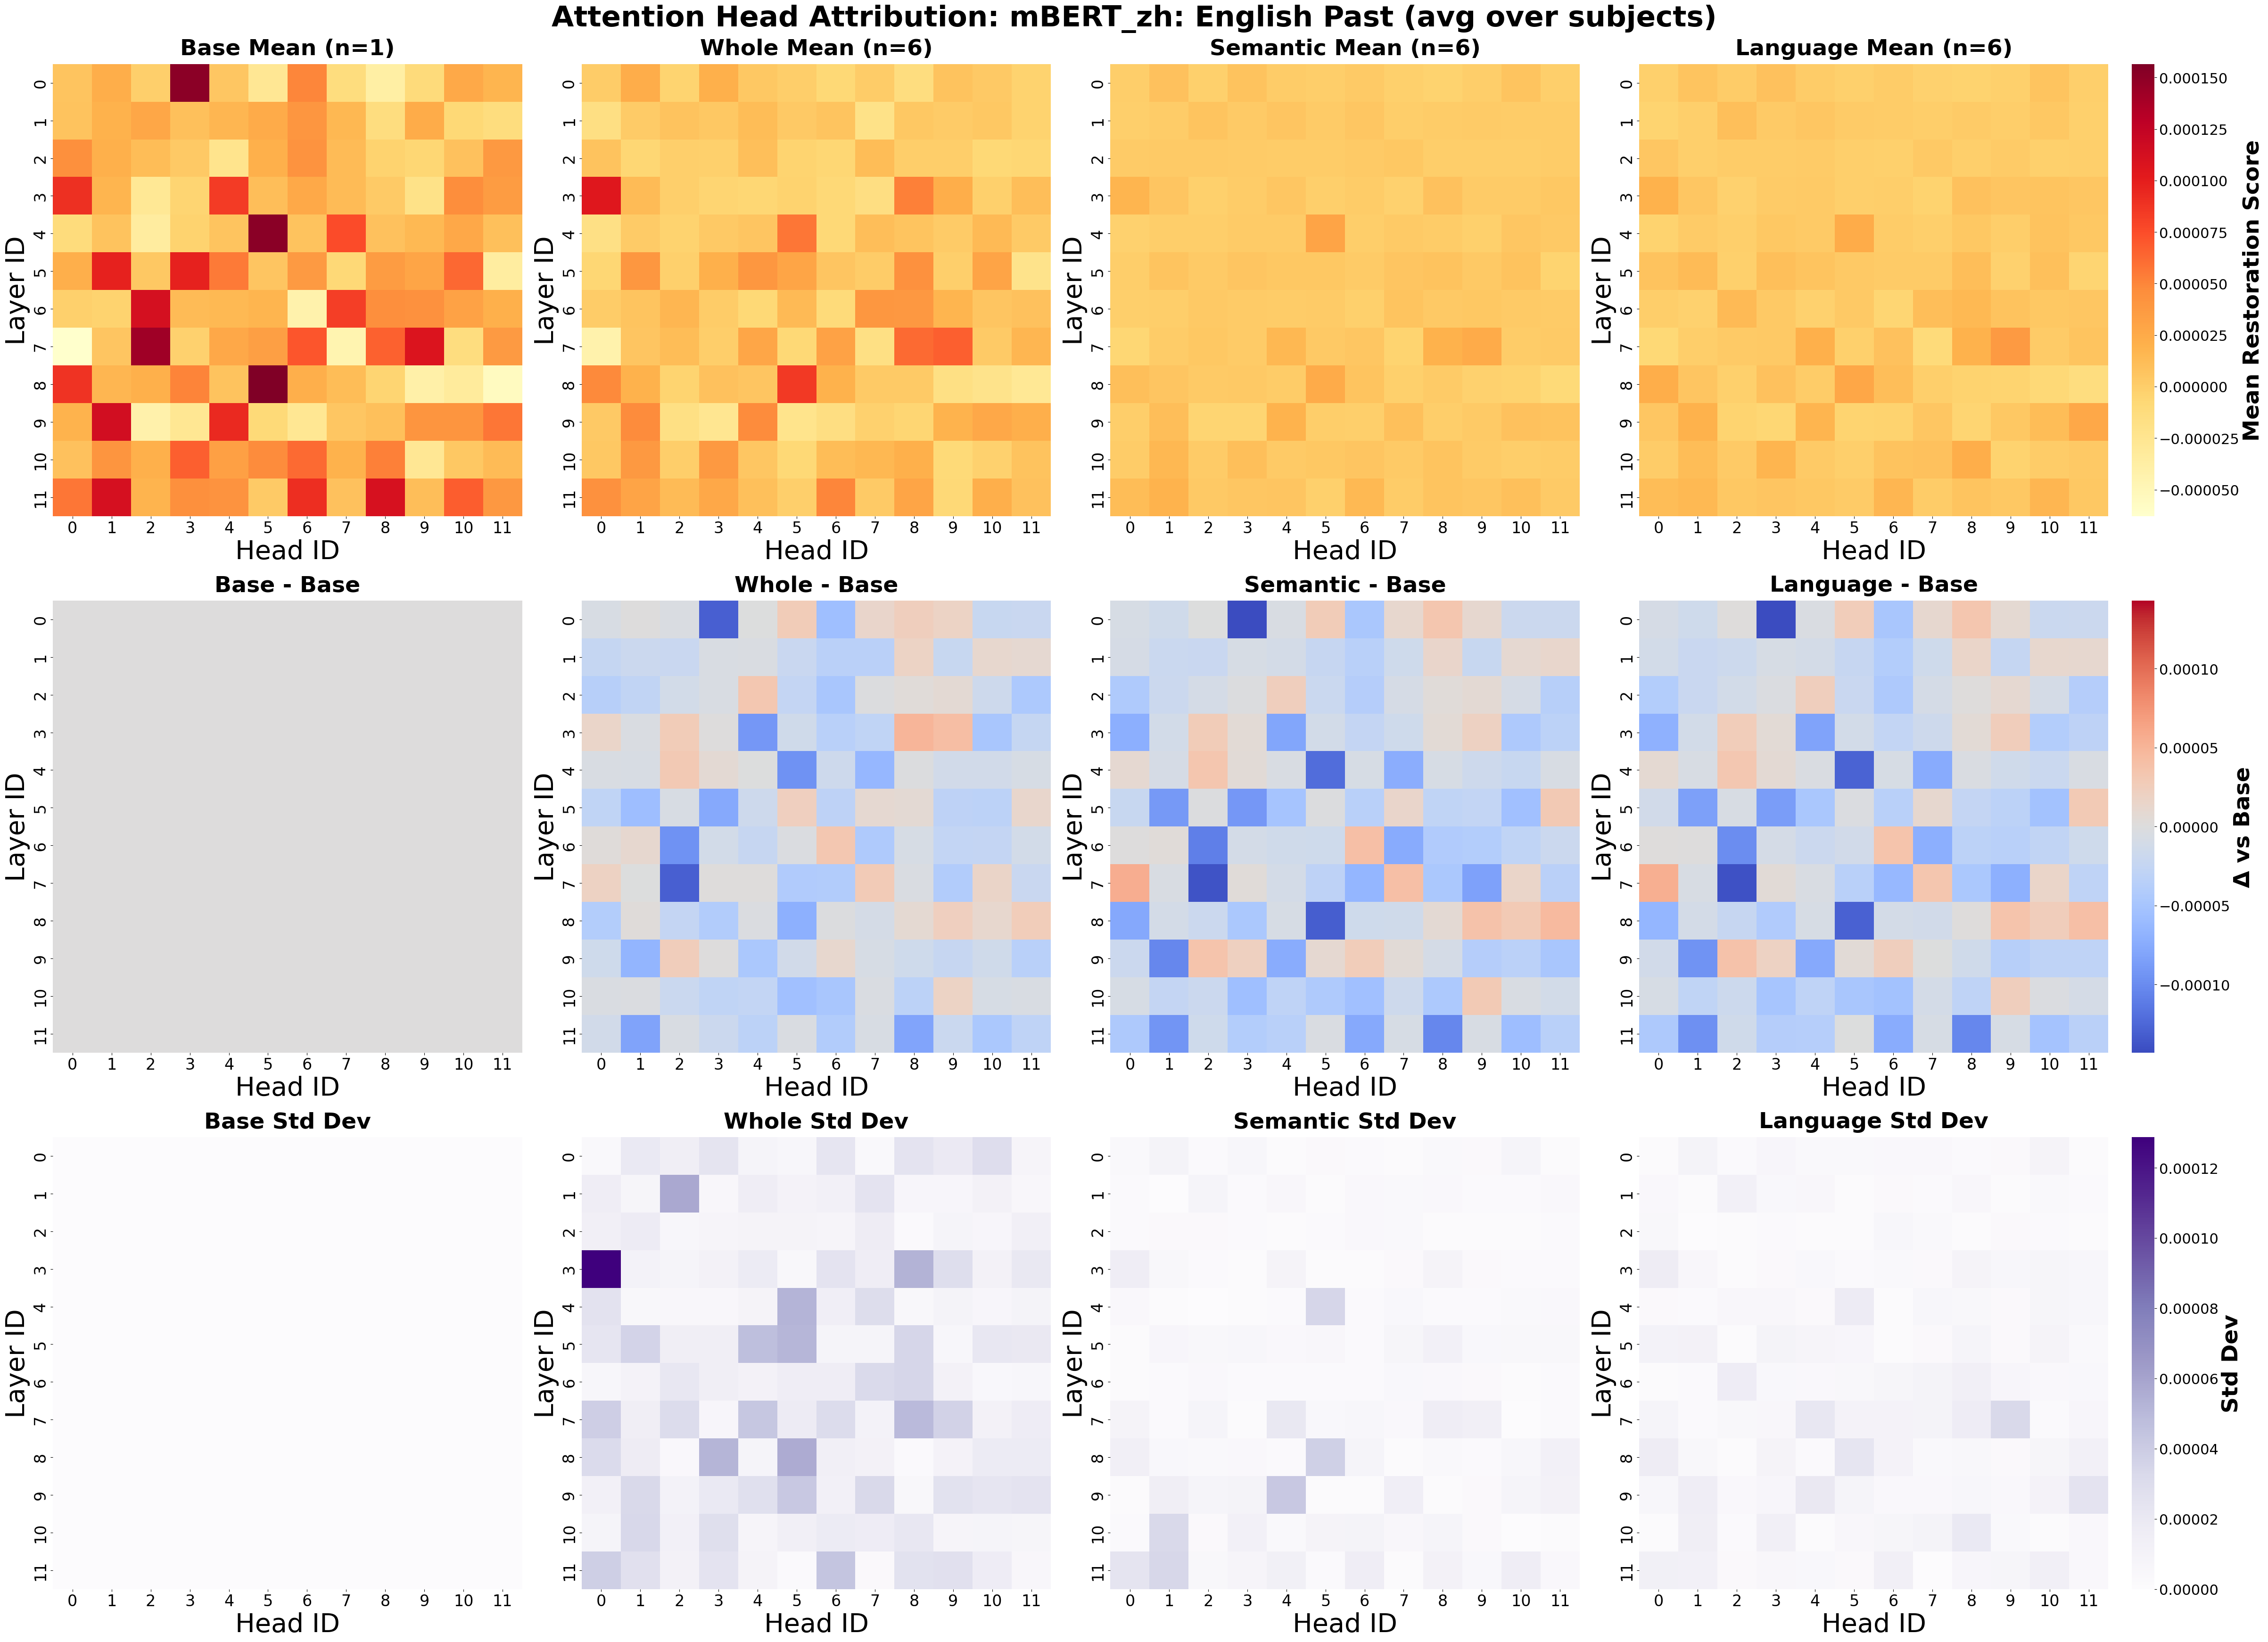

In [13]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="mBERT_zh",
    language="past_en",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="mBERT_zh: English Past (avg over subjects)")

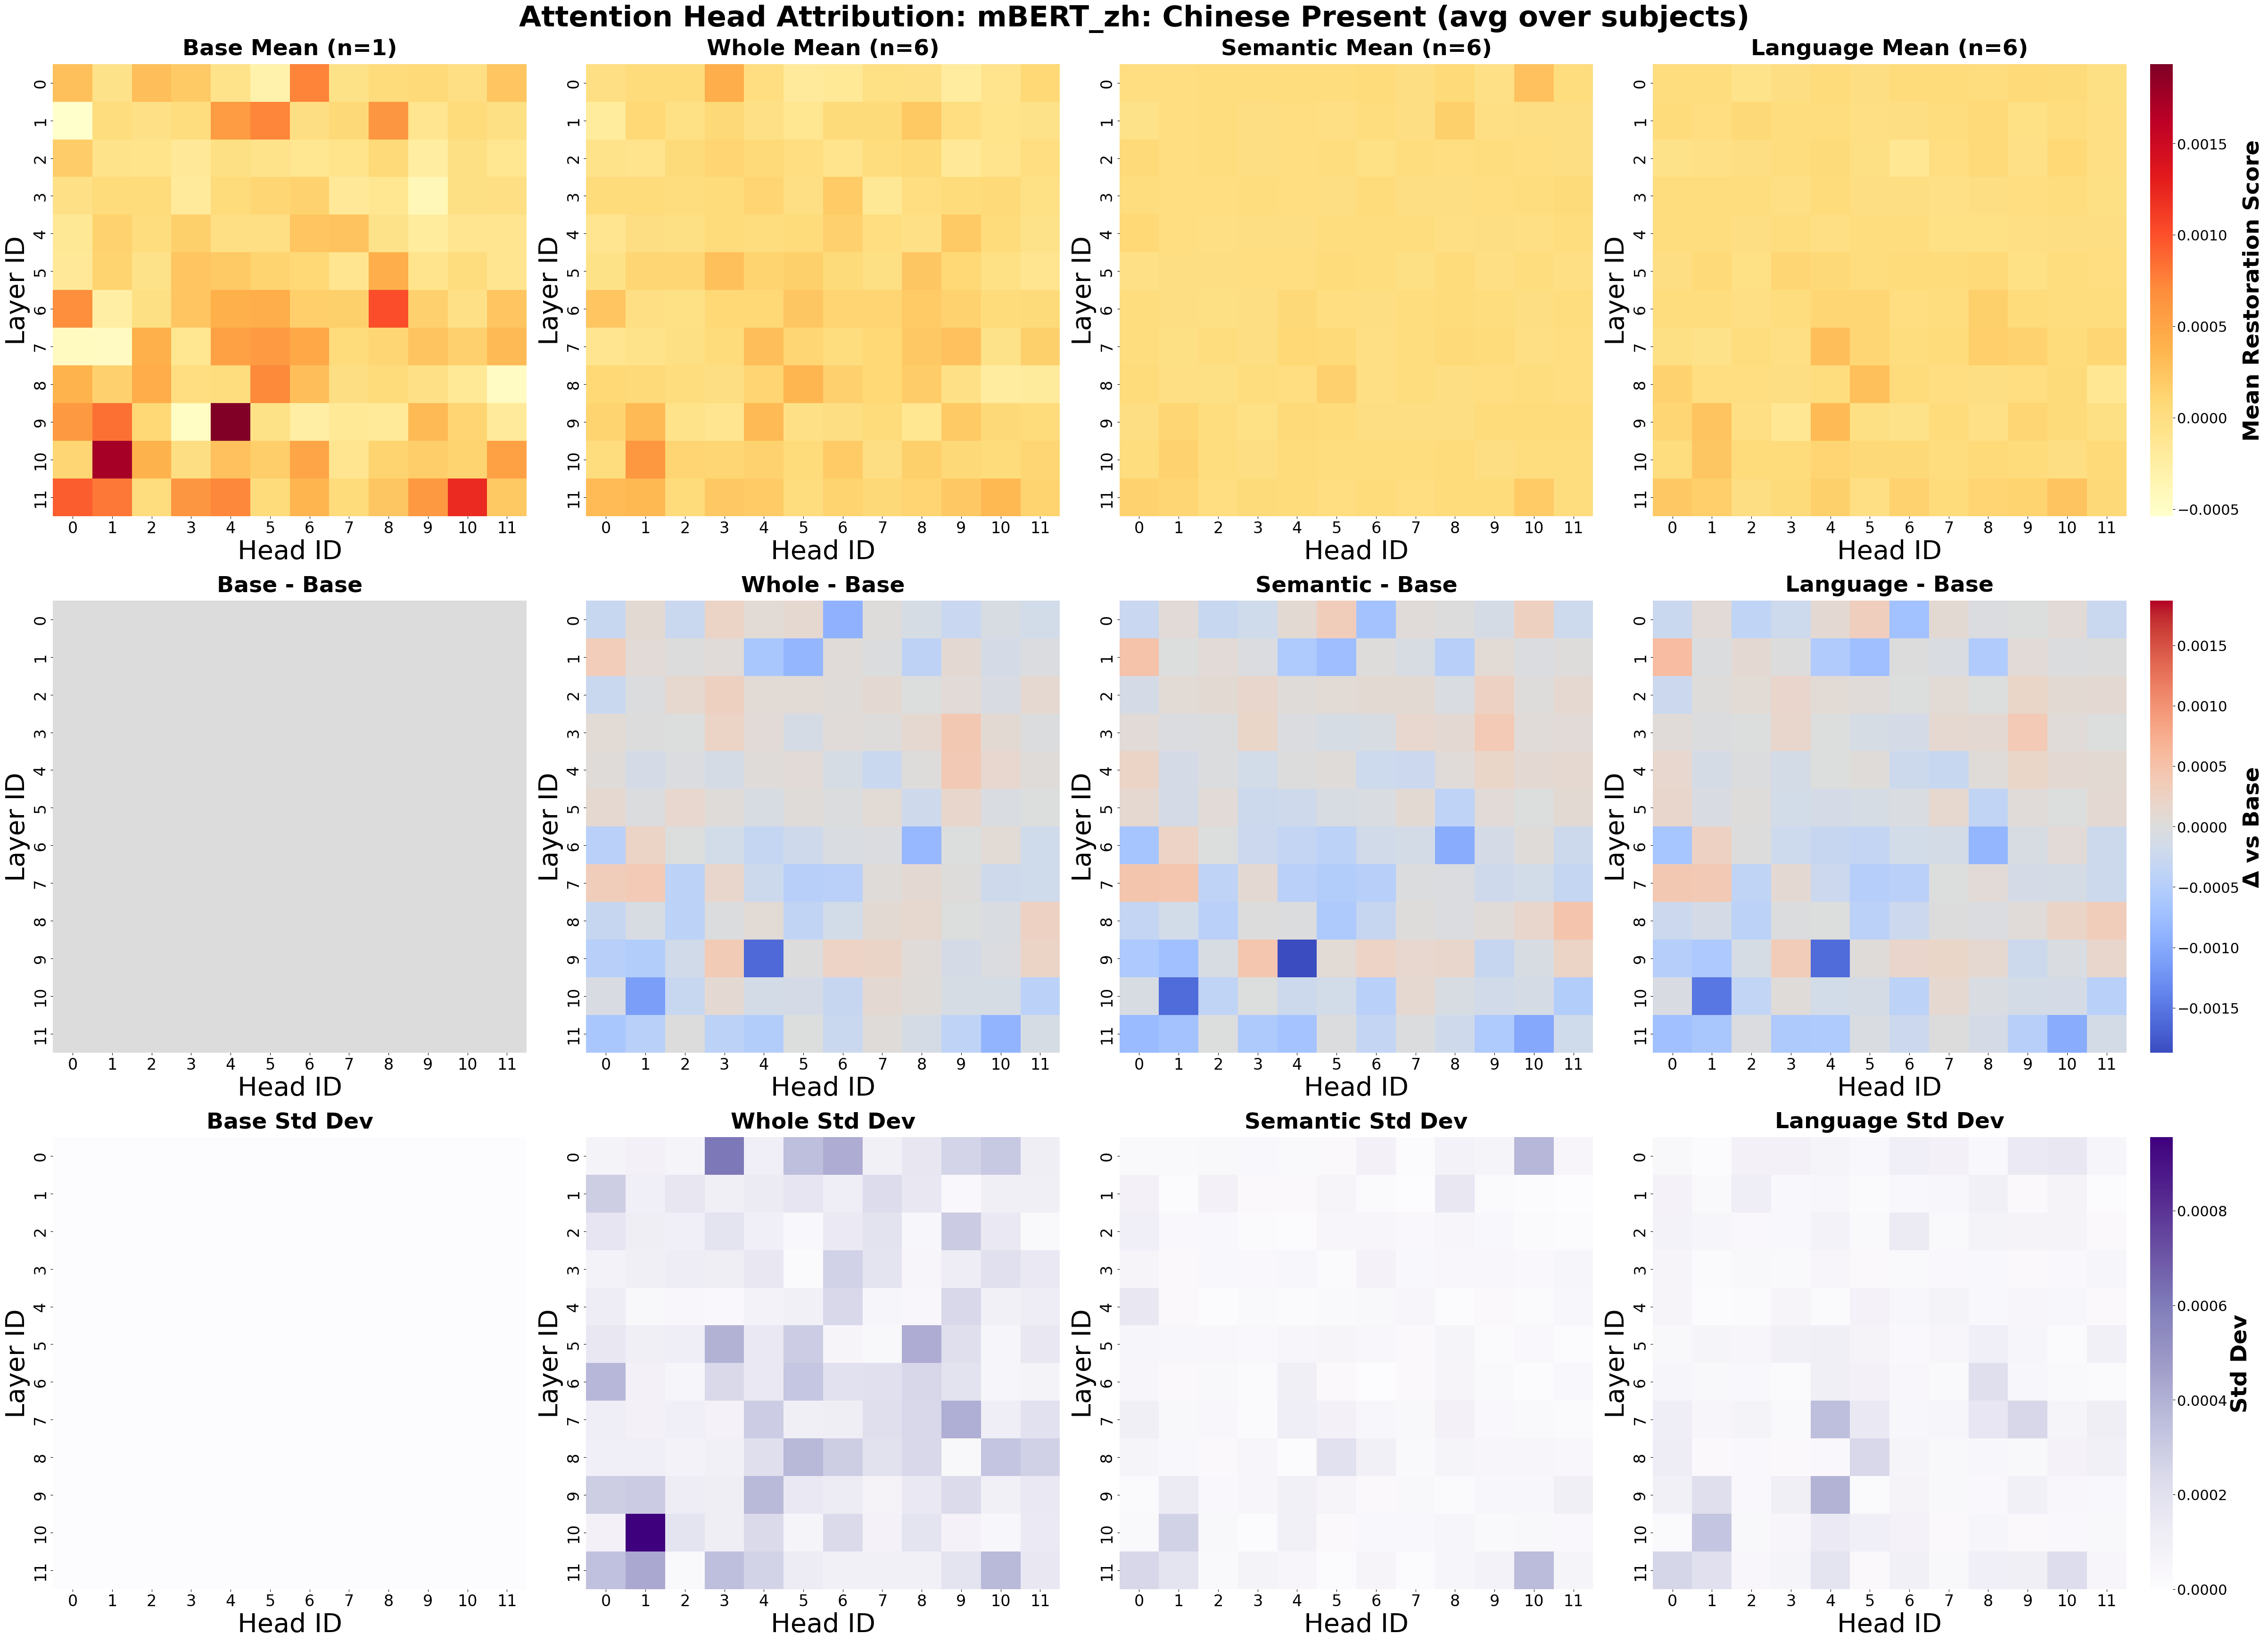

In [14]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="mBERT_zh",
    language="present_zh",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="mBERT_zh: Chinese Present (avg over subjects)")

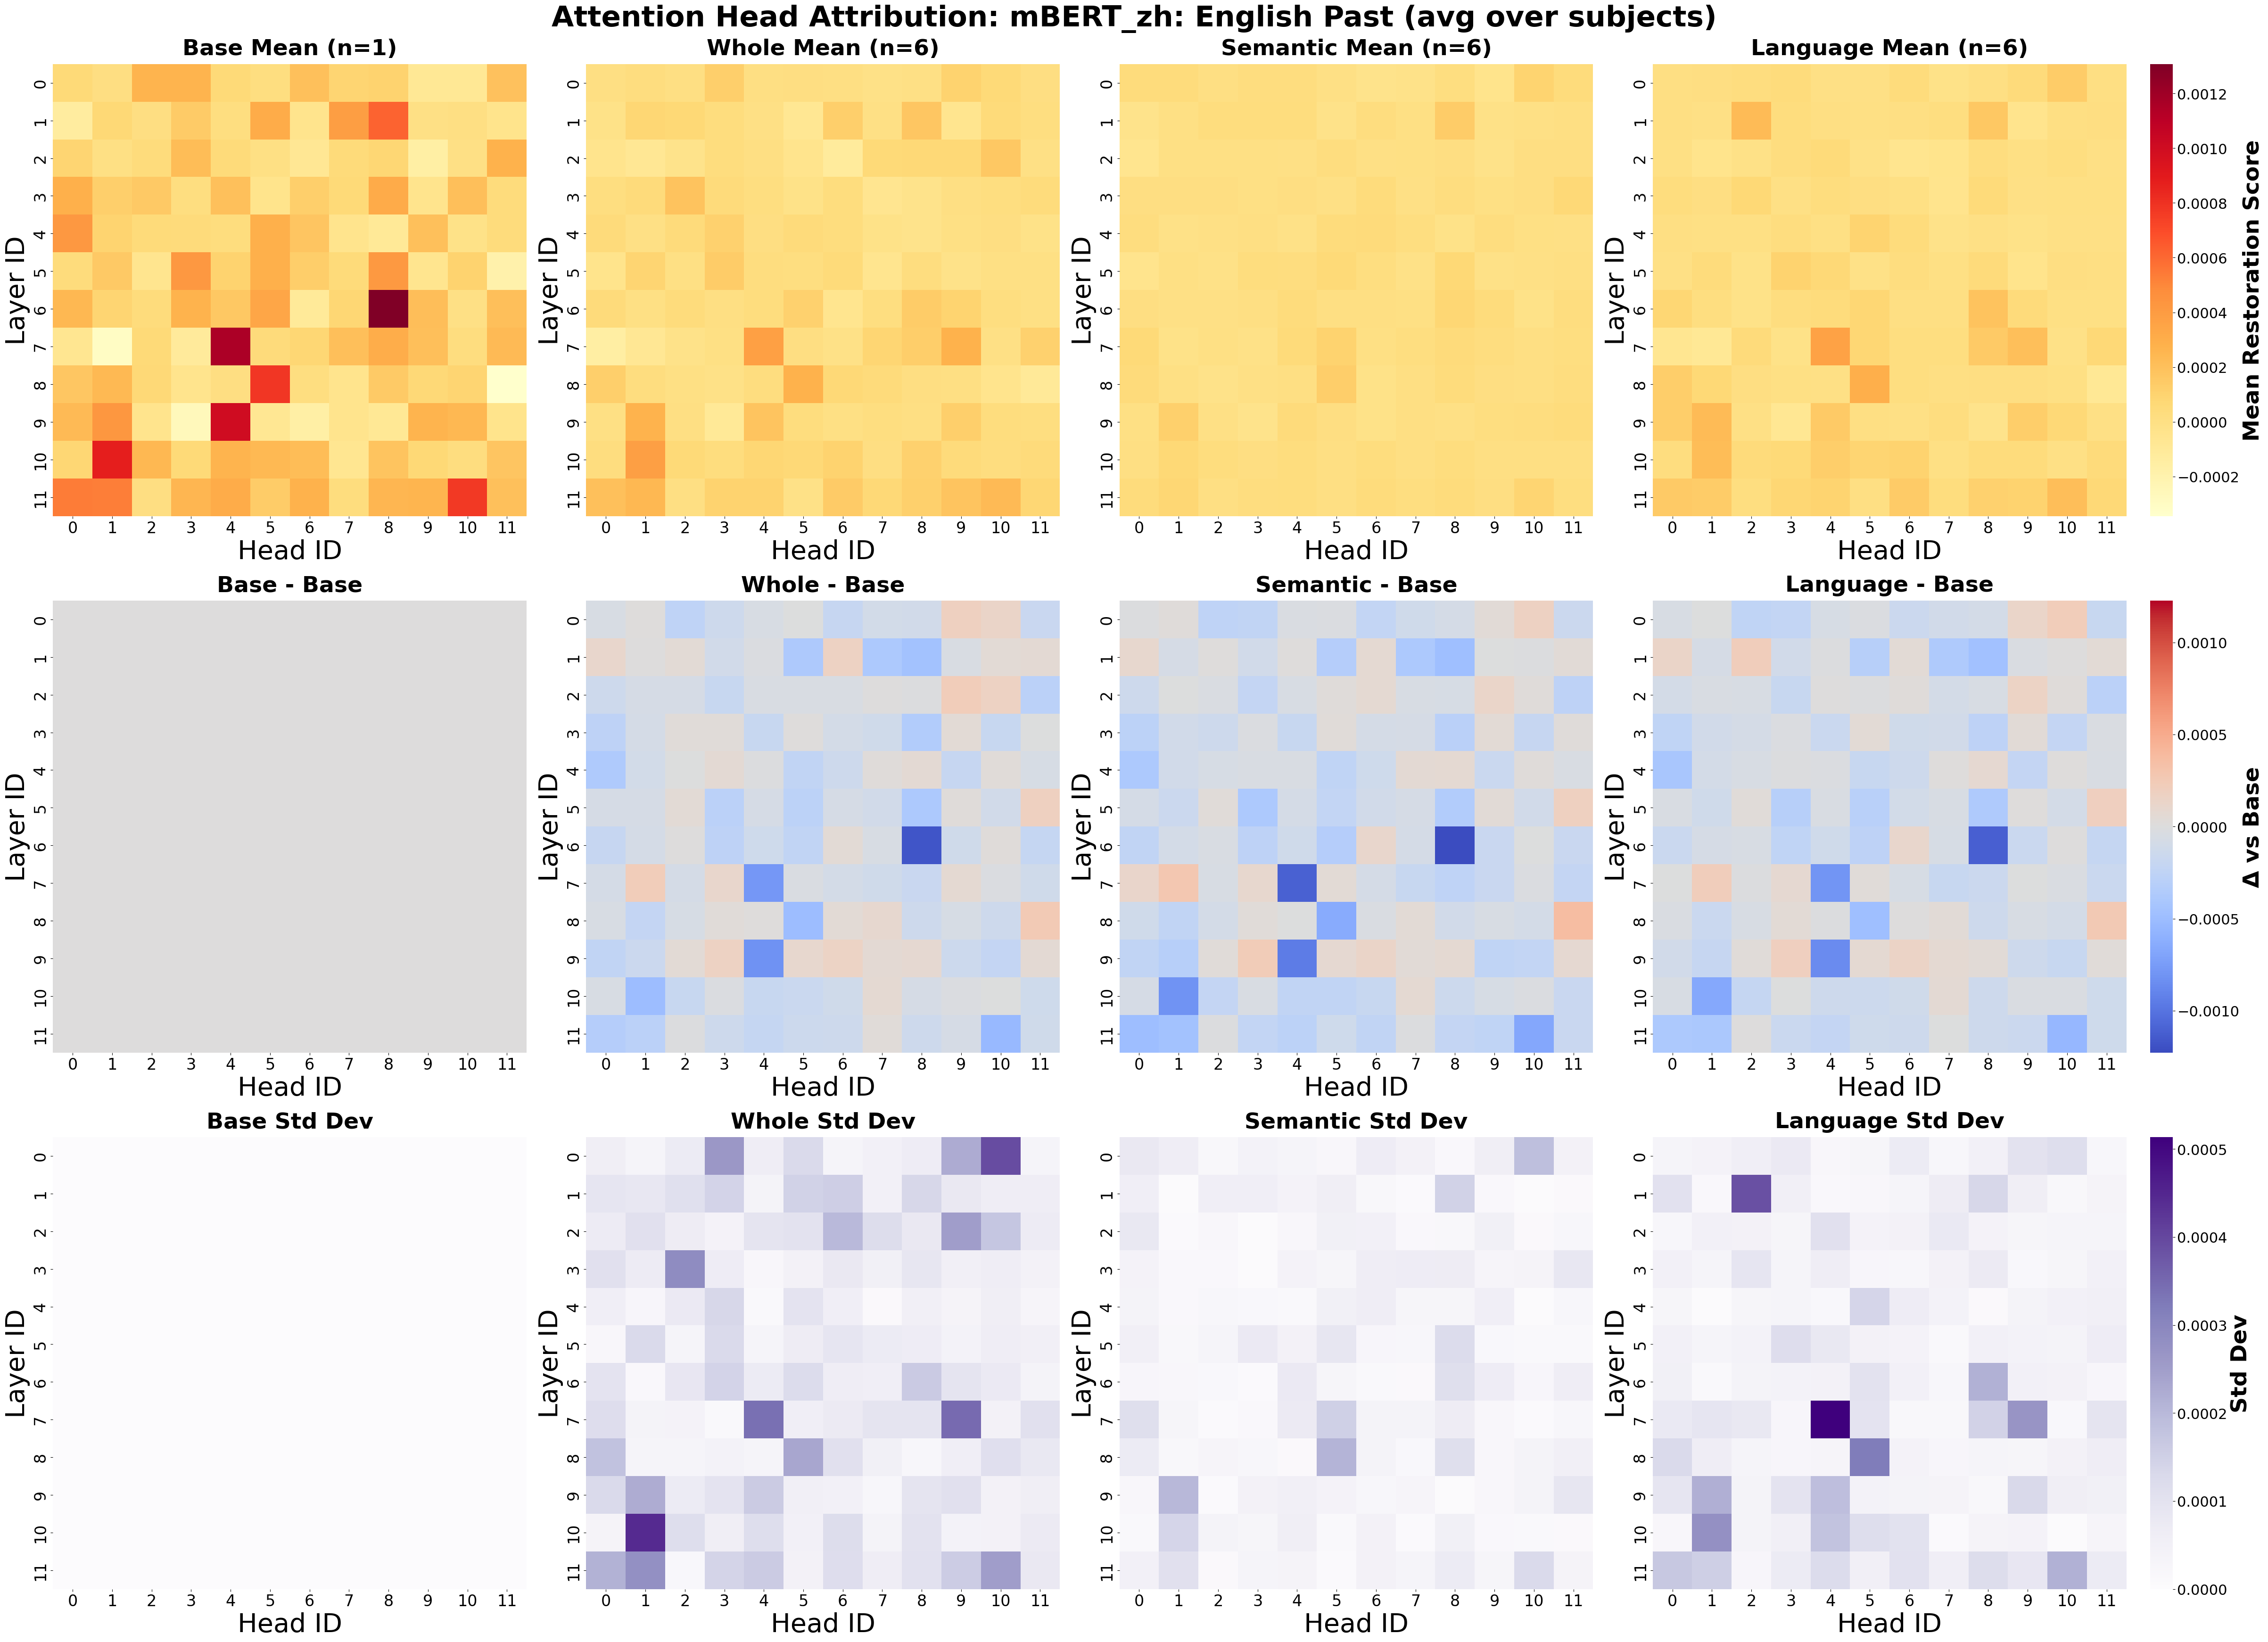

In [15]:
avg_res, std_results,  counts= patch_analyzer.load_family_attribution_avg(
    family_name="mBERT_zh",
    language="past_zh",
    subjects=subjects,
    folder_path="path_patching",
)
patch_analyzer.plot_family_grid_avg_diff(avg_res, std_results, counts, title_suffix="mBERT_zh: English Past (avg over subjects)")

In [16]:
import os, pickle, numpy as np

subjects = ["COL", "GFW", "JUS", "KOP", "TYE", "ZEK"]
folder = "path_patching"          # <-- must match what you used in run_family_attribution()
family_name = "mBERT_en"
language = "past_en"

bases = {}
for subj in subjects:
    path = os.path.join(folder, f"{family_name}_Subject-{subj}_{language}.pkl")
    with open(path, "rb") as f:
        res = pickle.load(f)
    bases[subj] = np.asarray(res["Base"])

ref_subj = subjects[0]
ref = bases[ref_subj]
print("Reference:", ref_subj, "shape:", ref.shape, "dtype:", ref.dtype)

for subj in subjects:
    x = bases[subj]
    print(
        subj,
        "same_shape:", x.shape == ref.shape,
        "array_equal:", np.array_equal(x, ref),
        "max_abs_diff:", float(np.max(np.abs(x - ref))),
    )


Reference: COL shape: (12, 12) dtype: float32
COL same_shape: True array_equal: True max_abs_diff: 0.0
GFW same_shape: True array_equal: False max_abs_diff: 3.453043245826848e-05
JUS same_shape: True array_equal: False max_abs_diff: 0.0001257113181054592
KOP same_shape: True array_equal: False max_abs_diff: 6.113528797868639e-05
TYE same_shape: True array_equal: False max_abs_diff: 5.026113649364561e-05
ZEK same_shape: True array_equal: False max_abs_diff: 0.00018464206368662417
